# Building a Model
In this notebook I will take the learnings from `data_exploration.ipynb` and build a multiple linear regression model with a few selected predictor variables.

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

resale_data_path = Path() / "data" / "resale_flat_prices_20260720.csv" # update path as necessary
ResalePrices = pd.read_csv(resale_data_path)

## Data Preparation and Train-Test Split

In [14]:
# basic data preparation without removing any outliers
def prepare_data(df):
    # drop the duplicates, re-number the index
    df = df.drop_duplicates(keep='first')
    # convert "month" to datetime datatype
    df['date'] = pd.to_datetime(ResalePrices['month'], format="%Y-%m", errors="coerce")
    # drop any rows with an invalid date
    df = df[~df['date'].isna()]
    # sort rows according to date, and re-number the index
    df = df.sort_values(by="date").reset_index(drop=True)

    # transform datatypes
    MIN_DATE = df['date'].min()
    df["regdate_months"] = (df['date'].dt.year * 12 + df['date'].dt.month) - (MIN_DATE.year * 12 + MIN_DATE.month)
    df['storey_range_cat'] = df['storey_range'].str.split(" TO ").str[1].astype(int) // 3
    ym = df['remaining_lease'].str.extract(r"(?:(\d+) years?)?\s?(?:(\d+) months?)?").fillna(0)
    df['remaining_lease_months'] = ym.loc[:, 0].astype(int) * 12 + ym.loc[:, 1].astype(int)

    # train-test split
    PREDICTORS = ["regdate_months", "storey_range_cat", "remaining_lease_months", "floor_area_sqm", "town", "flat_type", "flat_model"]
    RESPONSE = "resale_price"
    cutoff_date = df.iloc[int(df.shape[0] * 0.8)]['date']
    train = df[df['date'] <= cutoff_date]
    test = df[df['date'] > cutoff_date]

    X_train = train[PREDICTORS]
    X_test = test[PREDICTORS]
    y_train = train[RESPONSE]
    y_test = test[RESPONSE]

    return X_train, X_test, y_train, y_test

# separate function to remove outliers
def remove_outliers(df):
    return df

In [15]:
ResalePrices_Train, ResalePrices_Test, y_Train, y_Test = prepare_data(ResalePrices)
ResalePrices_Train

,regdate_months,storey_range_cat,remaining_lease_months,floor_area_sqm,town,flat_type,flat_model
0,0,4,736,44.0,ANG MO KIO,2 ROOM,Improved
1,0,1,981,100.0,SEMBAWANG,4 ROOM,Model A
2,0,2,976,100.0,SEMBAWANG,4 ROOM,Model A
3,0,1,990,86.0,SEMBAWANG,4 ROOM,Model A2
4,0,7,1067,110.0,QUEENSTOWN,5 ROOM,Improved
...,...,...,...,...,...,...,...
190505,92,1,725,63.0,KALLANG/WHAMPOA,3 ROOM,Simplified
190506,92,3,557,68.0,KALLANG/WHAMPOA,3 ROOM,Improved
190507,92,3,662,66.0,KALLANG/WHAMPOA,3 ROOM,Improved
190508,92,3,725,63.0,KALLANG/WHAMPOA,3 ROOM,Simplified


## Correlation

In [16]:
ResalePrices_Train[['regdate_months', 'storey_range_cat', 'remaining_lease_months', 'floor_area_sqm']].corr()

,regdate_months,storey_range_cat,remaining_lease_months,floor_area_sqm
regdate_months,1.000000,0.013117,-0.021792,-0.036926
storey_range_cat,0.013117,1.000000,0.274738,-0.014005
remaining_lease_months,-0.021792,0.274738,1.000000,0.117886
floor_area_sqm,-0.036926,-0.014005,0.117886,1.000000


## Modelling
In the notebook `data_exploration.ipynb`, there were multiple issues with the multiple linear regression with **all** predictor variables. Even though it achieved a decently high R^2 of `0.863` the Residual-Fitted plot shows nonlinearity.

In this section I will build a multiple linear regression with only selected variables, and visualize diagnostic plots to aid my decisions.

In [17]:
def build_design_matrix(df, cols):
    # supports building a design matrix M for these inputs:
    # - ["col1", "col2"]                    -> builds M with the desired columns (one-hot encode as needed)
    # - ["col1", ("col1", 2)]               -> builds M with "col1" and "col1"'s 2nd degree polynomial term
    # - ["col1", "col2", ("col1", "col2")]  -> builds M with "col1", "col2", and interaction between "col1" and "col2"
    # - ["col1", "col2", ("col1", 2), ("col1", "col2"), (("col1", 2), "col2")] -> last item adds interaction between "col1"'s 2nd degree poly and "col2"

    def get_col(col, transform=1):
        if col in ['regdate_months', 'storey_range_cat', 'remaining_lease_months', 'floor_area_sqm']:
            if transform == 1:
                return df[[col]]
            elif transform == "log": # do a logarithm instead
                return np.log(df[[col]]).add_suffix("(log)")
            else:
                return (df[[col]] ** transform).add_suffix(f"^{transform}")
        else: # 'town', 'flat_type', 'flat_model'
            return pd.get_dummies(df[[col]], columns=[col], drop_first=True, dtype=int)

    X = pd.DataFrame()
    for col in cols:
        # add individual predictor
        if type(col) is str:
            X = pd.concat([X, get_col(col)], axis=1)

        # add polynomial term or interaction term
        if type(col) is tuple:
            # polynomial term
            if type(col[1]) is int or type(col[1]) is float or col[1] == "log":
                X = pd.concat([X, get_col(col[0], col[1])], axis=1)

            # interaction term
            else:
                col1 = col[0]
                col2 = col[1]
                int1 = get_col(col1) if type(col1) is str else get_col(col1[0], col1[1])
                int2 = get_col(col2) if type(col2) is str else get_col(col2[0], col2[1])

                # compute the pairwise products using numpy broadcasting
                # (n, m1, 1) * (n, 1, m2) -> (n, m1, m2)
                products = int1.to_numpy()[:, :, None] * int2.to_numpy()[:, None, :]
                # reshape to (n, m1 * m2)
                prod_matrix = products.reshape(len(int1), -1)
                # generate descriptive column names
                col_names = [f"{c1}*{c2}" for c1 in int1.columns for c2 in int2.columns]
                # construct dataframe with product matrix
                interaction = pd.DataFrame(prod_matrix, index=int1.index, columns=col_names)
                # drop any columns without data (e.g. there are no flat_type_MULTI-GENERATION homes in town_BEDOK)
                interaction = interaction.loc[:, (interaction != 0).any(axis=0)]

                X = pd.concat([X, interaction], axis=1)

    X = sm.add_constant(X)
    return X

In [18]:
def plot_diagnostics(result, title=None):
    fig, axs = plt.subplots(figsize=(16, 4), ncols=4)
    if title:
        fig.suptitle(title)

    # residual vs fitted value
    axs[0].scatter(result.fittedvalues, result.resid)
    axs[0].axhline(y=0, c='b', ls='--', label="residual = 0")
    delta = 0.01 * (result.fittedvalues.max() - result.fittedvalues.min()) # use an appropriate delta to save computation time
    lowess = sm.nonparametric.lowess(result.resid, result.fittedvalues, delta=delta, return_sorted=True)
    lowess_x = lowess[:, 0]
    lowess_y = lowess[:, 1]
    axs[0].plot(lowess_x, lowess_y, c='r', ls='--', label="LOWESS line")
    axs[0].set_ylabel("Residual")
    axs[0].set_xlabel("Fitted Values")
    axs[0].legend()

    # q-q plot of residual quantile distribution vs theoretical normal distribution
    sm.qqplot(result.get_influence().resid_studentized_internal, loc=0, scale=1, line="45", ax=axs[1])

    # scale-location plot
    scale_location_y = np.sqrt(np.abs(result.get_influence().resid_studentized_internal))
    axs[2].scatter(result.fittedvalues, scale_location_y)
    delta = 0.01 * (result.fittedvalues.max() - result.fittedvalues.min())
    lowess = sm.nonparametric.lowess(scale_location_y, result.fittedvalues, delta=delta, return_sorted=True)
    lowess_x = lowess[:, 0]
    lowess_y = lowess[:, 1]
    axs[2].plot(lowess_x, lowess_y, c='r', ls='--', label="LOWESS line")
    axs[2].set_ylabel("sqrt(abs(Studentized Residual))")
    axs[2].set_xlabel("Fitted Values")
    axs[2].legend()

    # residual vs leverage
    stud_resid = result.get_influence().resid_studentized_internal
    leverage = result.get_influence().hat_matrix_diag
    num_predictors = len(result.model.exog_names) - 1
    axs[3].scatter(leverage, stud_resid)
    leverage_x = np.linspace(leverage.min(), leverage.max(), 50)
    cooks_dist_001 = np.sqrt(0.01 * num_predictors * (1 - leverage_x) / leverage_x) # Cook's Dist = 0.01
    cooks_dist_0001 = np.sqrt(0.001 * num_predictors * (1 - leverage_x) / leverage_x) # Cook's Dist = 0.001
    axs[3].set_xlim(*axs[3].get_xlim()) # set limits before plotting Cook's Distance
    axs[3].set_ylim(*axs[3].get_ylim())
    axs[3].plot(leverage_x, cooks_dist_001, c='r', ls='--', label="Cook's Distance = 0.01")
    axs[3].plot(leverage_x, -cooks_dist_001, c='r', ls='--')
    axs[3].plot(leverage_x, cooks_dist_0001, c='orange', ls='--', label="Cook's Distance = 0.001")
    axs[3].plot(leverage_x, -cooks_dist_0001, c='orange', ls='--')
    axs[3].set_xlabel("Leverage")
    axs[3].set_ylabel("Studentized Residual")
    axs[3].legend()

    plt.tight_layout()

In [19]:
def test_predictors(train, test, curr, new_preds):
    results = []
    for feature_key, preds in new_preds.items():
        cols = [*curr, *preds]
        X = build_design_matrix(train, cols)
        result = sm.OLS(test, X).fit()
        results.append({
            'feature': feature_key,
            'f_pvalue': result.f_pvalue,
            'rsquared': result.rsquared,
            'rsquared_adj': result.rsquared_adj,
            'aic': result.aic,
            'bic': result.bic,
        })
        print(result.summary())
        plot_diagnostics(result, title=f"Diagnostics for resale_prices vs {cols}")
    return pd.DataFrame(results).set_index('feature')

### 1 Predictor Variable
Here I conduct univariate modelling, with polynomials for selected predictors (added based on the shapes in the residual plots). 
I also test the difference between simply using the response as-is, or applying a log(Y) transformation to the response.

#### `Y` (no transformation)

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                 2.418e+04
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:37:43   Log-Likelihood:            -2.5598e+06
No. Observations:              190510   AIC:                         5.120e+06
Df Residuals:                  190508   BIC:                         5.120e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.941e+05    802.727    490.

,f_pvalue,rsquared,rsquared_adj,aic,bic
feature,,,,,
regdate_months,0.0,0.112632,0.112627,5.119565e+06,5.119585e+06
storey_range_cat,0.0,0.123212,0.123208,5.117280e+06,5.117300e+06
floor_area_sqm,0.0,0.352635,0.352631,5.059488e+06,5.059508e+06
floor_area_sqm (polynomial),0.0,0.354411,0.354404,5.058967e+06,5.058997e+06
remaining_lease_months,0.0,0.101376,0.101371,5.121966e+06,5.121987e+06
remaining_lease_months (polynomial),0.0,0.113023,0.113013,5.119483e+06,5.119514e+06
town,0.0,0.107197,0.107080,5.120776e+06,5.121040e+06
flat_type,0.0,0.373684,0.373664,5.053200e+06,5.053272e+06
flat_model,0.0,0.285623,0.285548,5.078291e+06,5.078504e+06


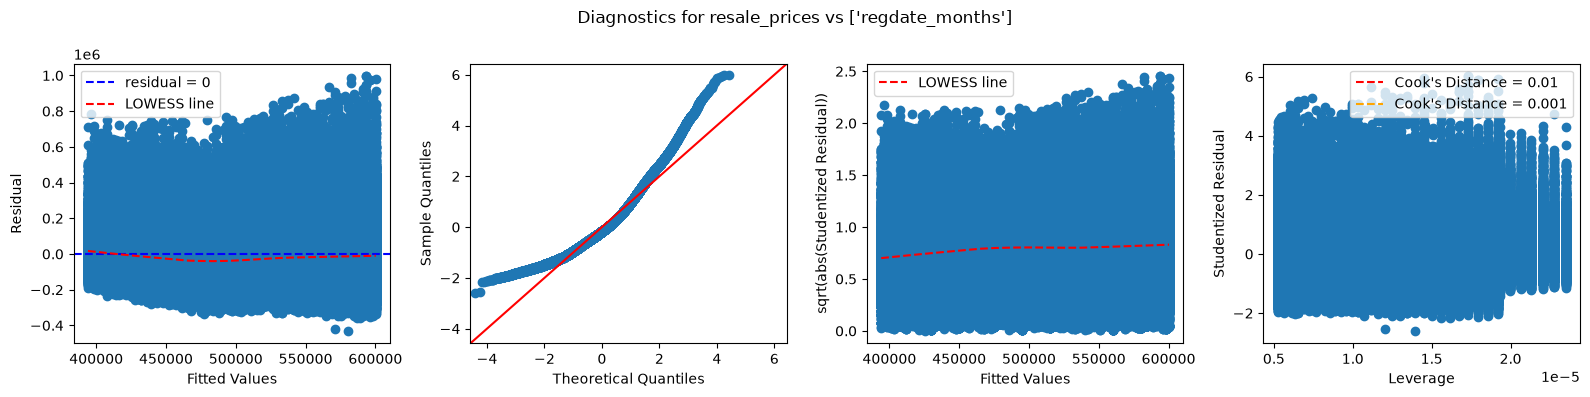

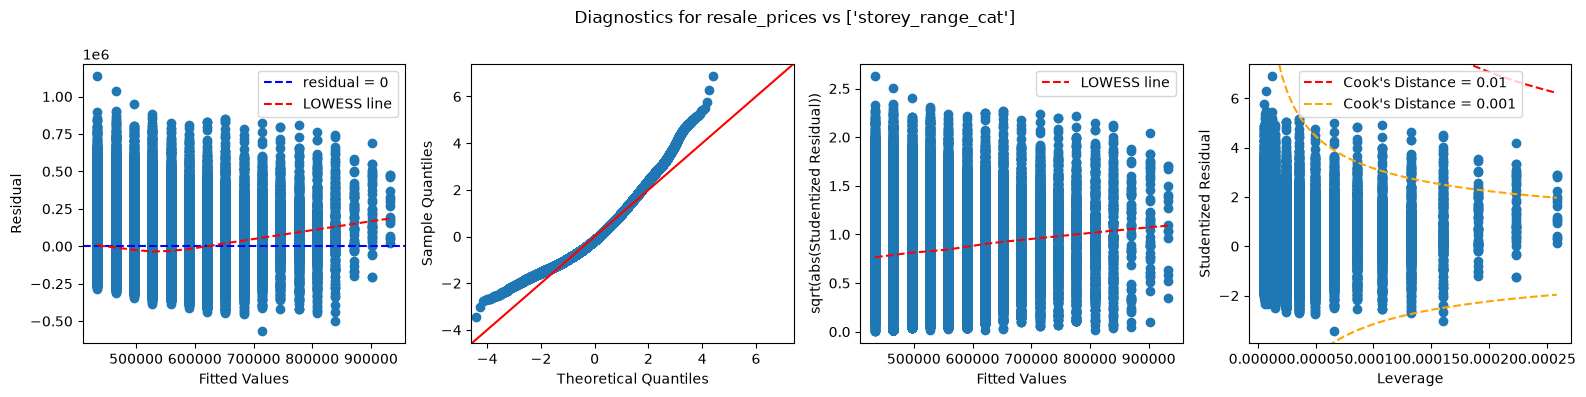

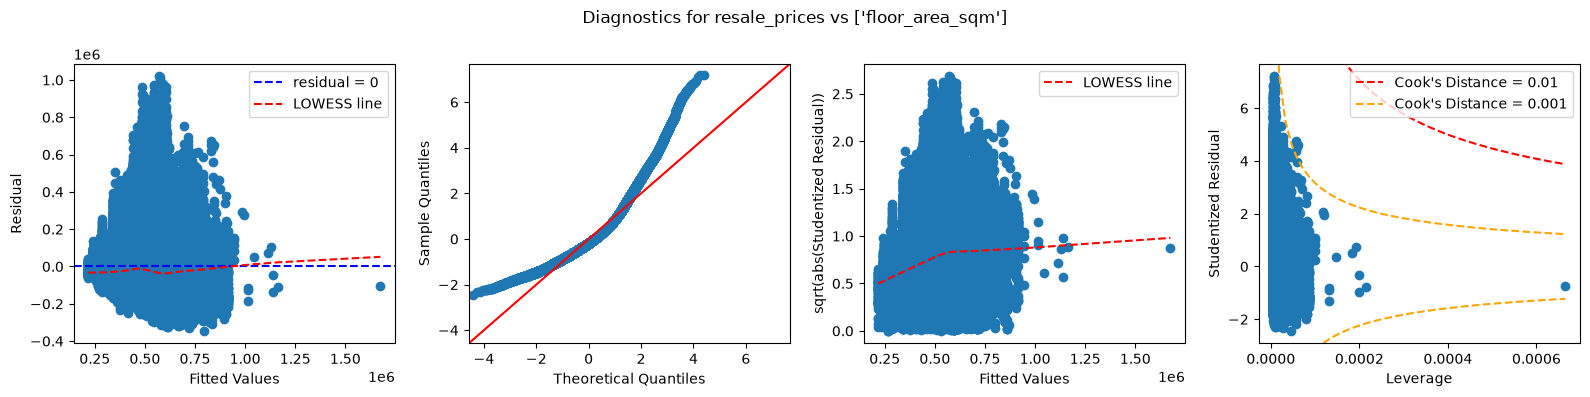

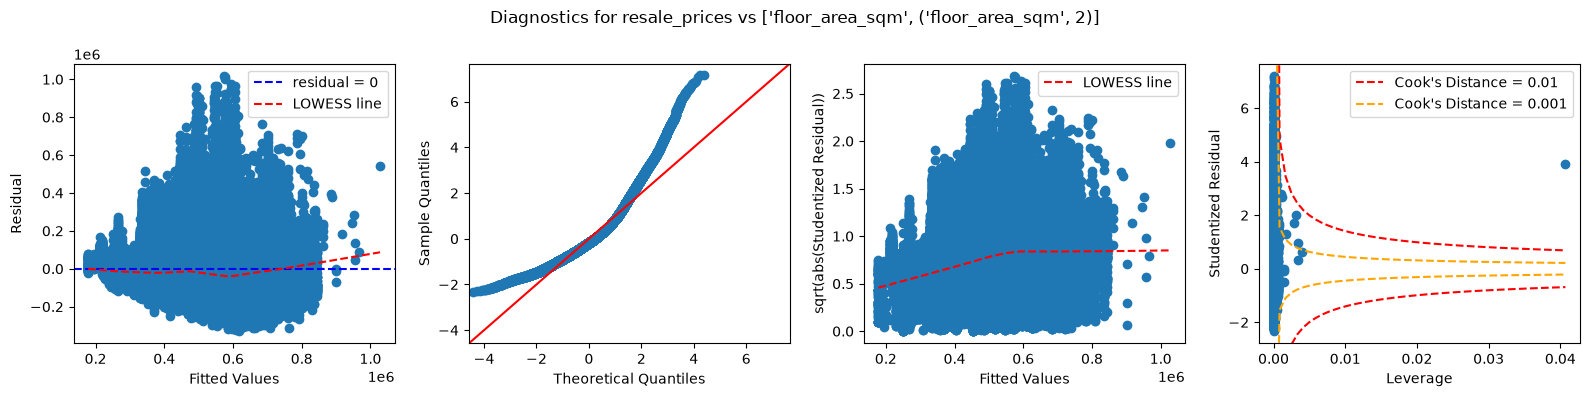

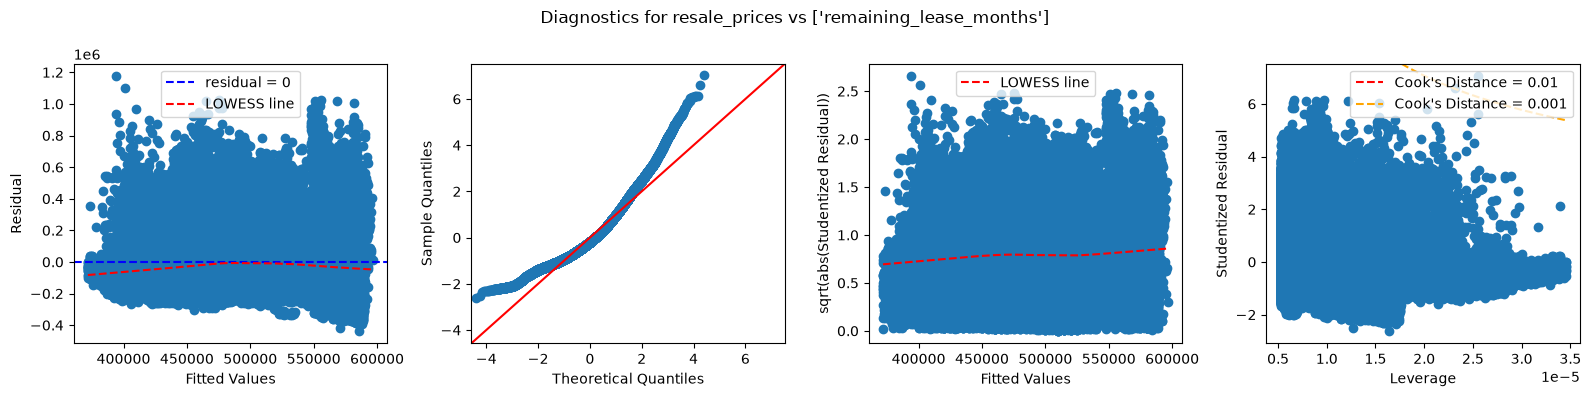

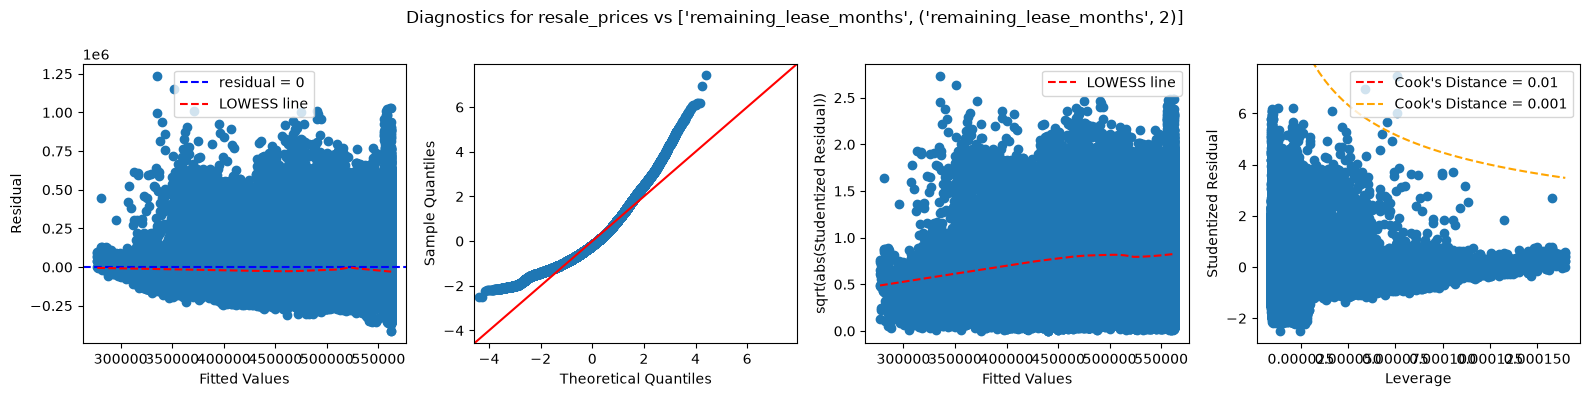

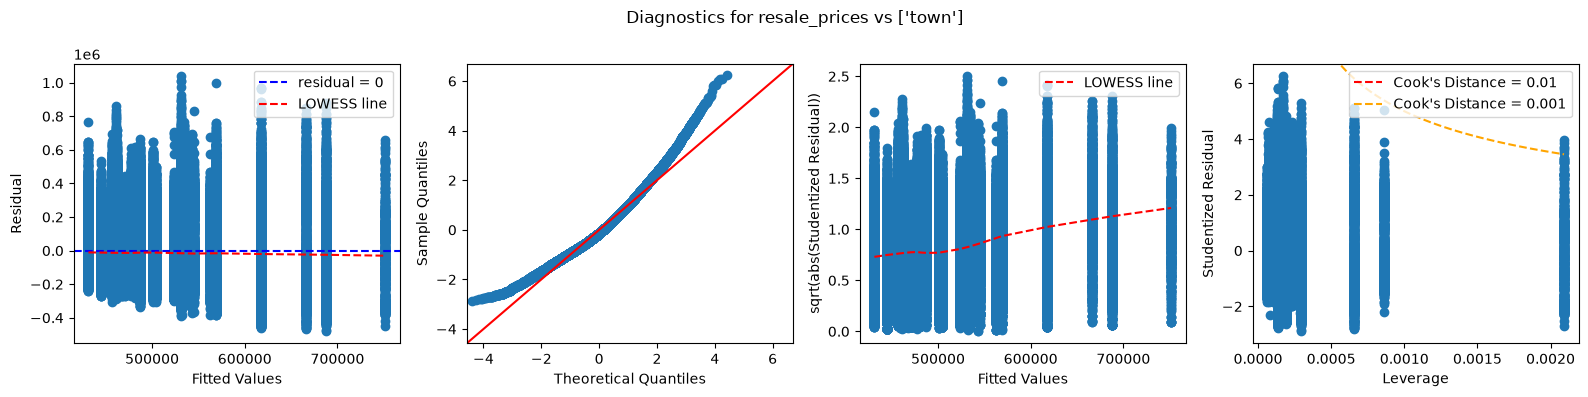

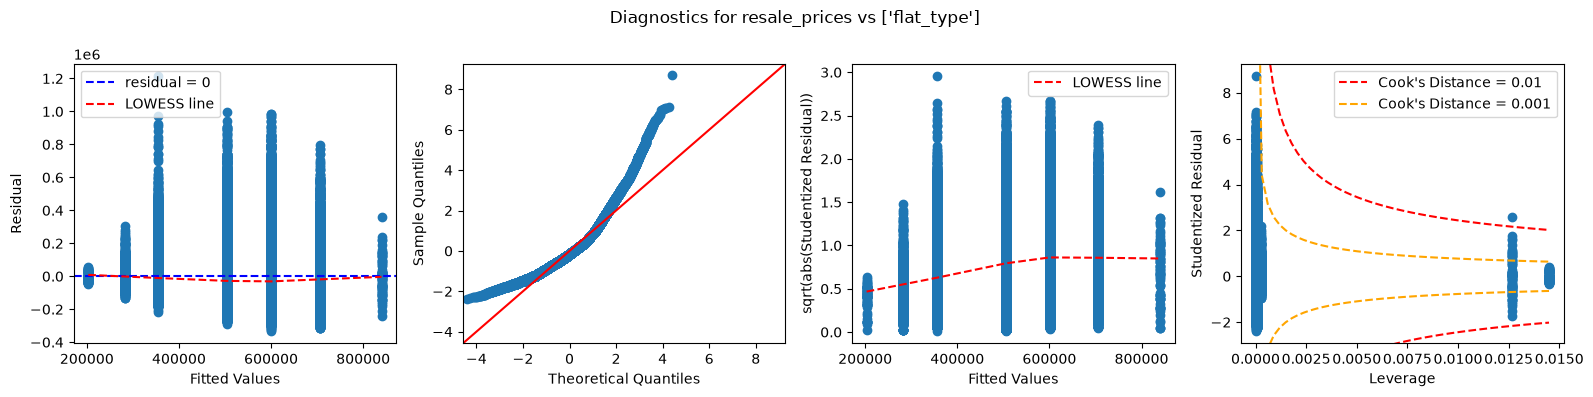

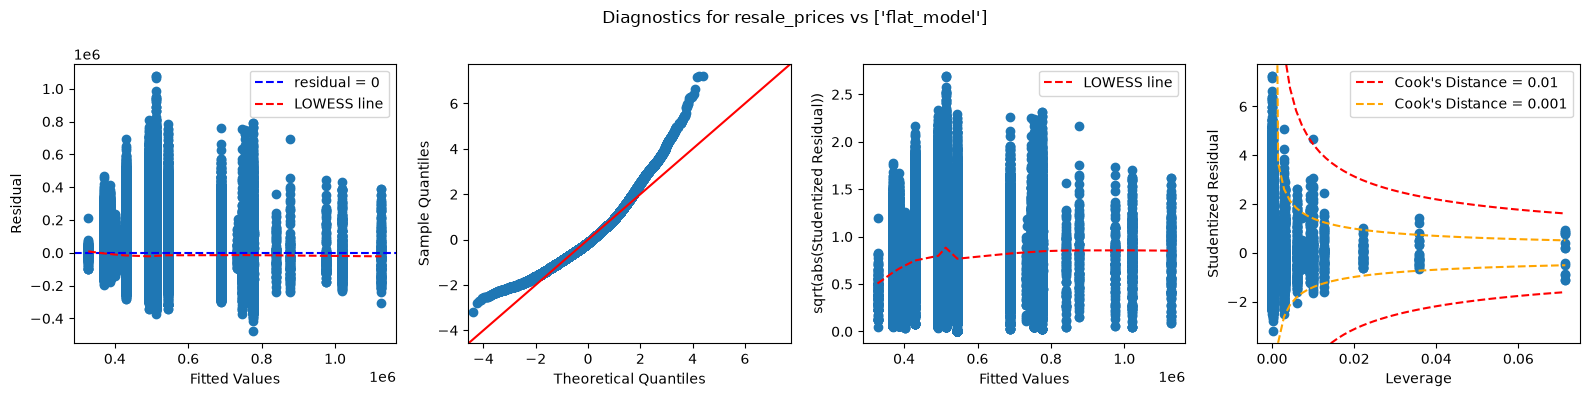

In [20]:
test_predictors(ResalePrices_Train, y_Train, [], {
    'regdate_months': ['regdate_months'],
    'storey_range_cat': ['storey_range_cat'],
    'floor_area_sqm': ['floor_area_sqm'],
    'floor_area_sqm (polynomial)': ['floor_area_sqm', ('floor_area_sqm', 2)],
    'remaining_lease_months': ['remaining_lease_months'],
    'remaining_lease_months (polynomial)': ['remaining_lease_months', ('remaining_lease_months', 2)],
    'town': ['town'],
    'flat_type': ['flat_type'],
    'flat_model': ['flat_model'],
})

#### `log(Y)` transformation

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                 2.726e+04
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:38:52   Log-Likelihood:                -51743.
No. Observations:              190510   AIC:                         1.035e+05
Df Residuals:                  190508   BIC:                         1.035e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             12.8489      0.002   8350.

,f_pvalue,rsquared,rsquared_adj,aic,bic
feature,,,,,
regdate_months,0.0,0.125171,0.125166,103489.991542,103510.306462
storey_range_cat,0.0,0.104321,0.104316,107977.128122,107997.443042
floor_area_sqm,0.0,0.407752,0.407749,29171.293500,29191.608420
floor_area_sqm (polynomial),0.0,0.422210,0.422204,24464.991832,24495.464212
remaining_lease_months,0.0,0.127395,0.127390,103005.014058,103025.328978
remaining_lease_months (polynomial),0.0,0.146949,0.146940,98689.407882,98719.880262
town,0.0,0.092914,0.092795,110436.143504,110700.237464
flat_type,0.0,0.441804,0.441786,17900.472306,17971.574526
flat_model,0.0,0.269624,0.269548,69146.709086,69360.015746


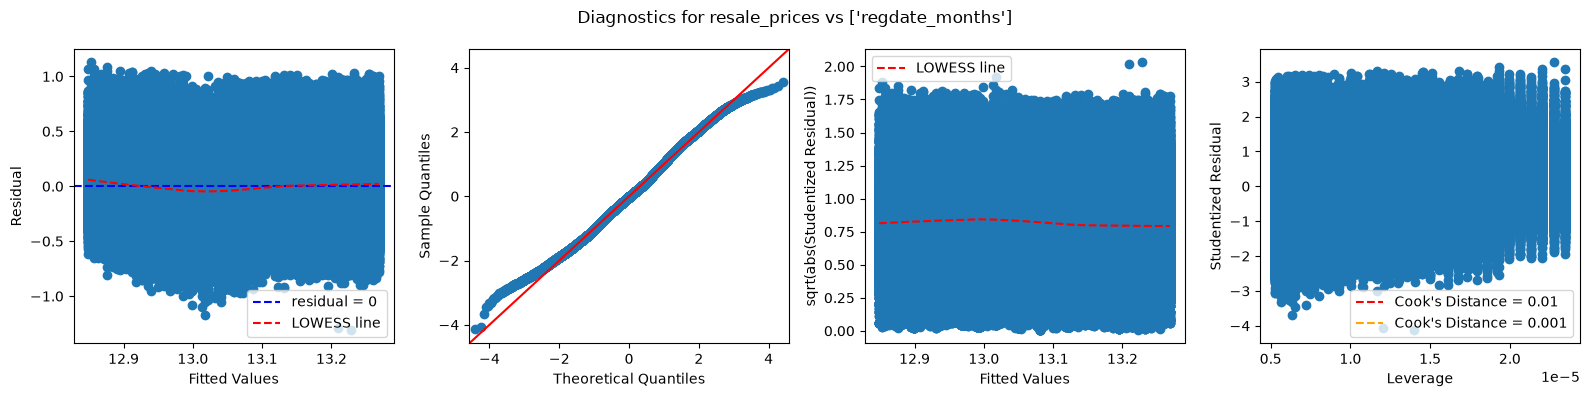

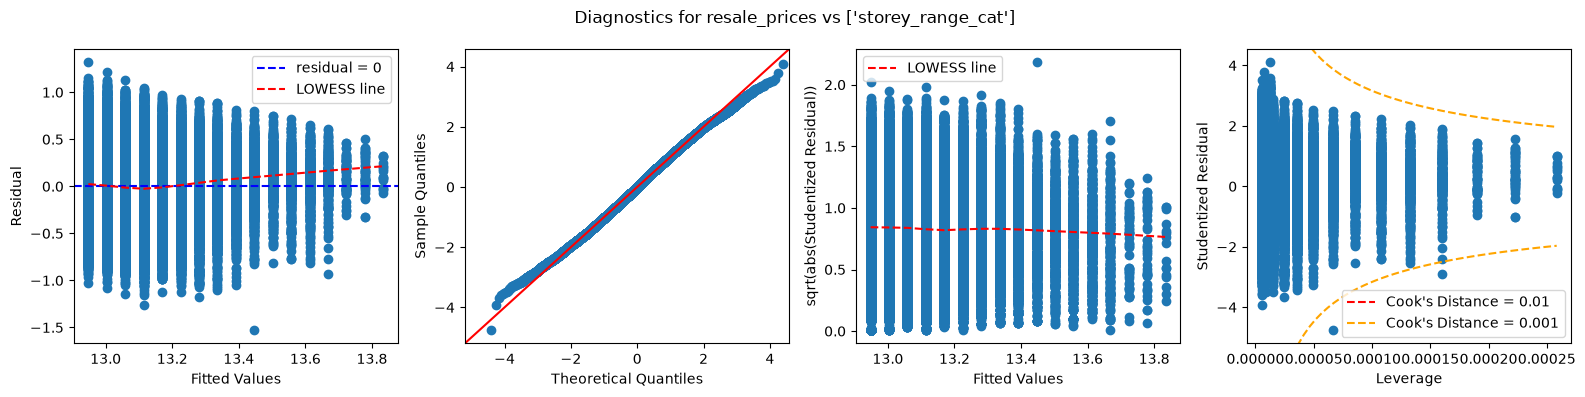

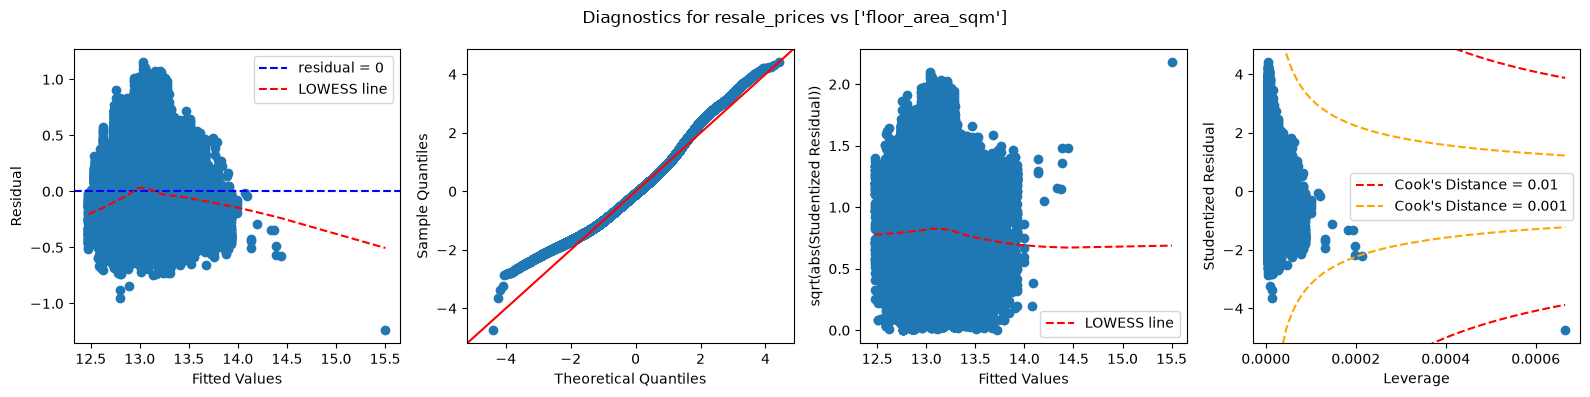

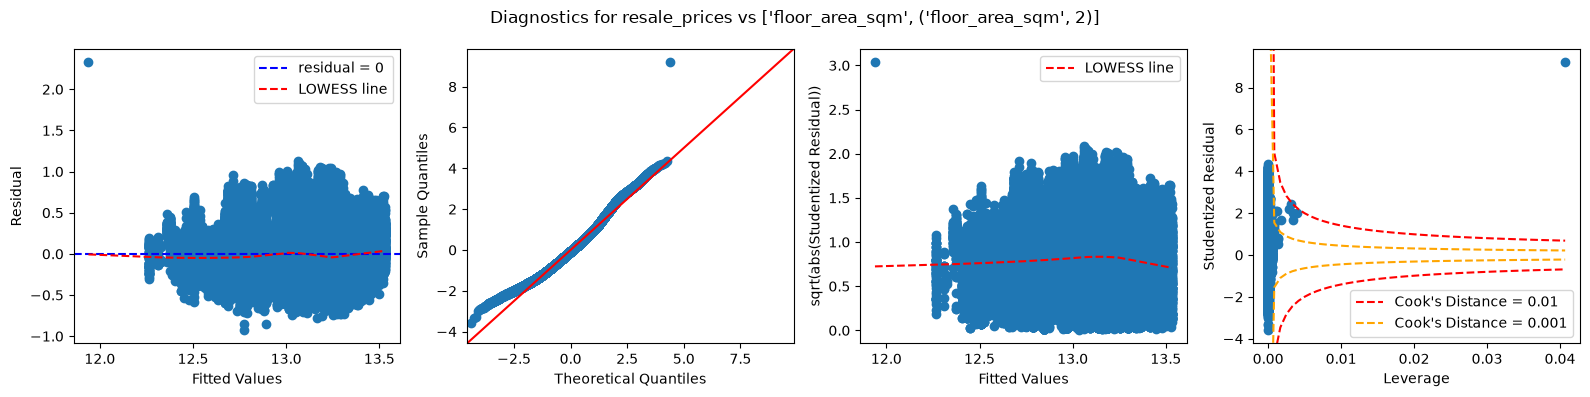

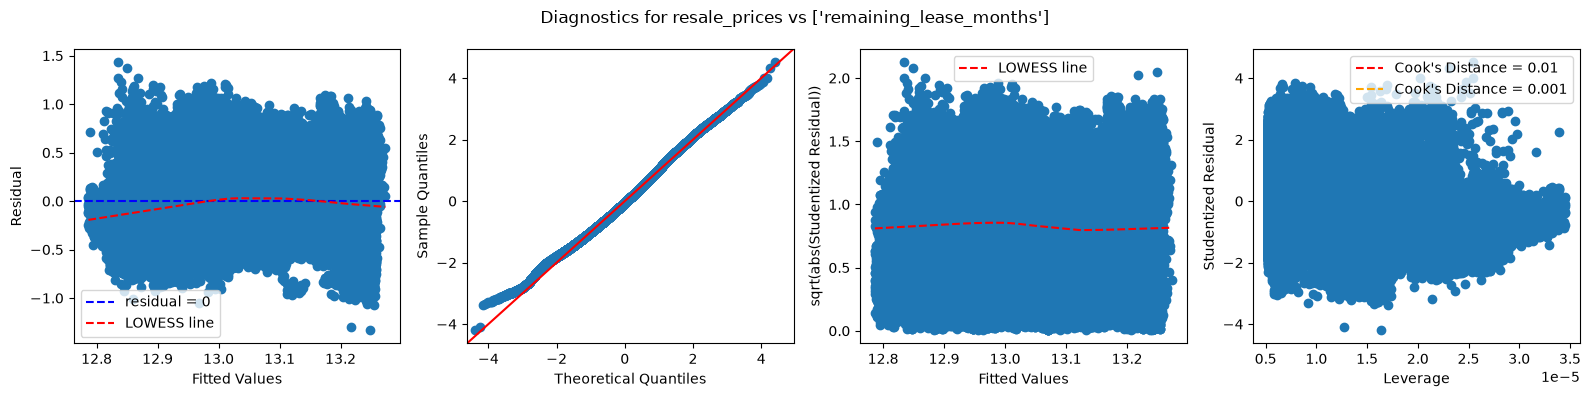

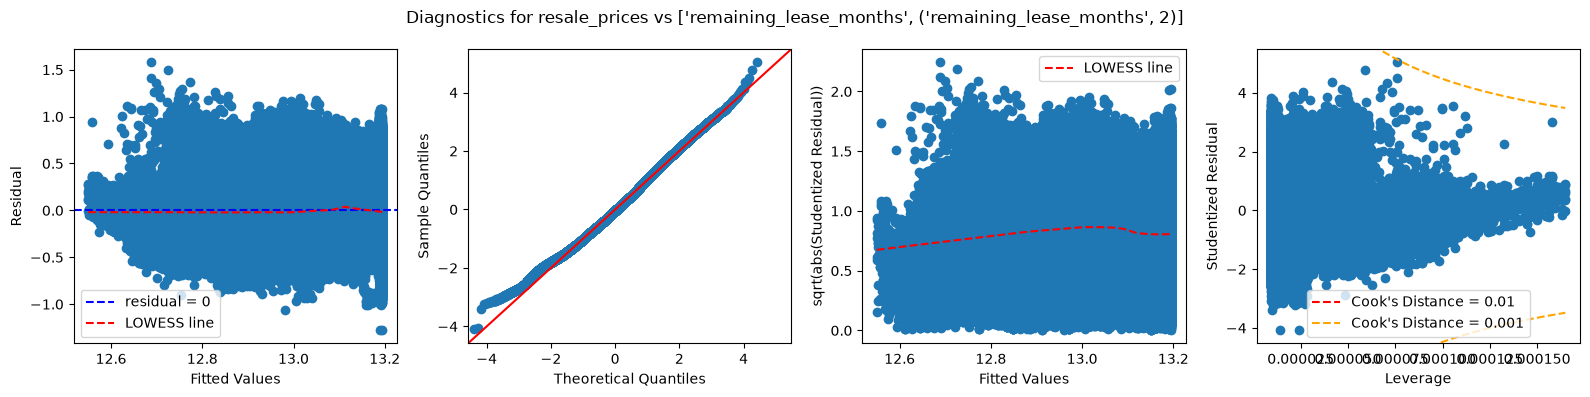

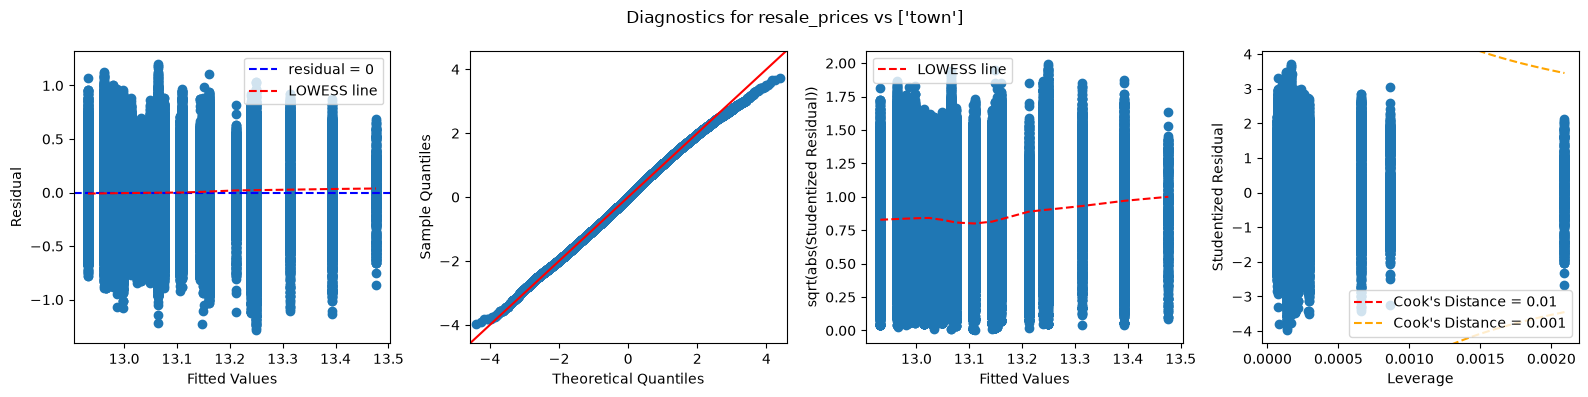

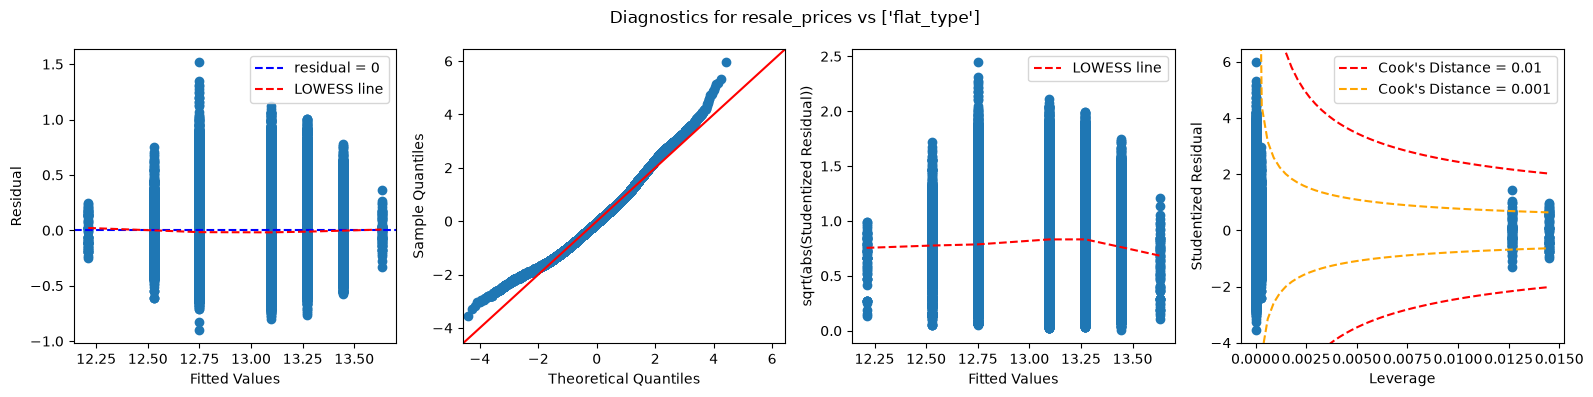

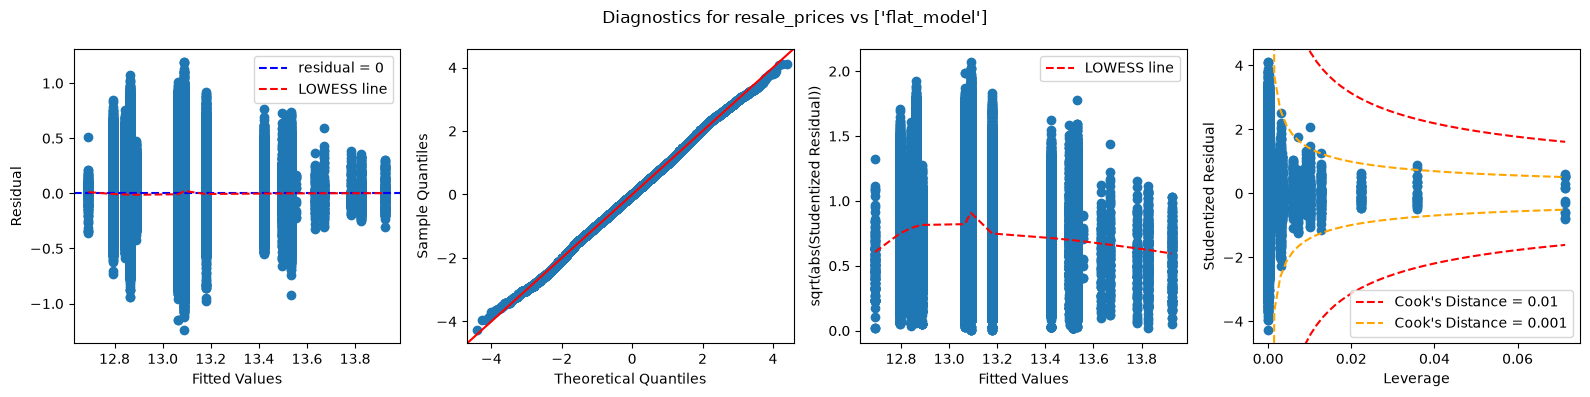

In [21]:
test_predictors(ResalePrices_Train, np.log(y_Train), [], {
    'regdate_months': ['regdate_months'],
    'storey_range_cat': ['storey_range_cat'],
    'floor_area_sqm': ['floor_area_sqm'],
    'floor_area_sqm (polynomial)': ['floor_area_sqm', ('floor_area_sqm', 2)],
    'remaining_lease_months': ['remaining_lease_months'],
    'remaining_lease_months (polynomial)': ['remaining_lease_months', ('remaining_lease_months', 2)],
    'town': ['town'],
    'flat_type': ['flat_type'],
    'flat_model': ['flat_model'],
})

#### 1 Predictor Model Conclusion
The log(Y) transformation showed overall higher R-squared values, and better Residual-Fitted Value plots and Q-Q normality plots. Hence for the following more complex models I will go with the log(Y) transformation.

As for the best predictor, I will select `flat_type` because it has the highest R^2 and lowest bic value, while showing reasonable diagnostic plots.

### 2 Predictor Variables

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                 3.761e+04
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:40:03   Log-Likelihood:                 18195.
No. Observations:              190510   AIC:                        -3.637e+04
Df Residuals:                  190502   BIC:                        -3.629e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,f_pvalue,rsquared,rsquared_adj,aic,bic
feature,,,,,
regdate_months,0.0,0.580189,0.580173,-36374.799050,-36293.539370
storey_range_cat,0.0,0.527833,0.527816,-13984.707356,-13903.447677
floor_area_sqm,0.0,0.444723,0.444703,16903.320678,16984.580357
remaining_lease_months,0.0,0.486990,0.486971,1820.367806,1901.627485
town,0.0,0.578117,0.578048,-35389.112493,-35064.073774
flat_model,0.0,0.523712,0.523649,-12293.104792,-12029.010833


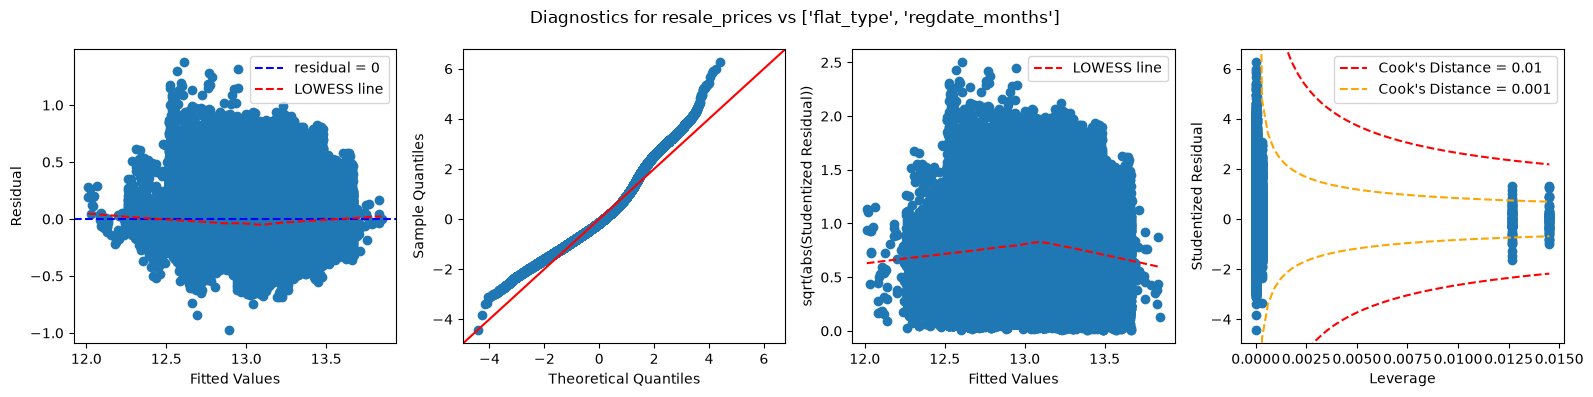

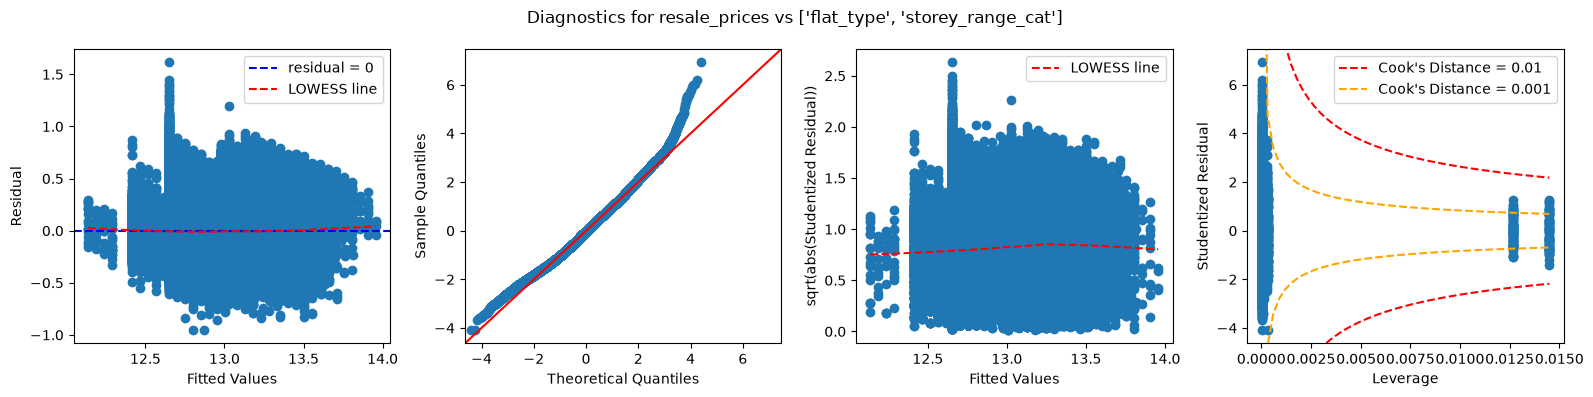

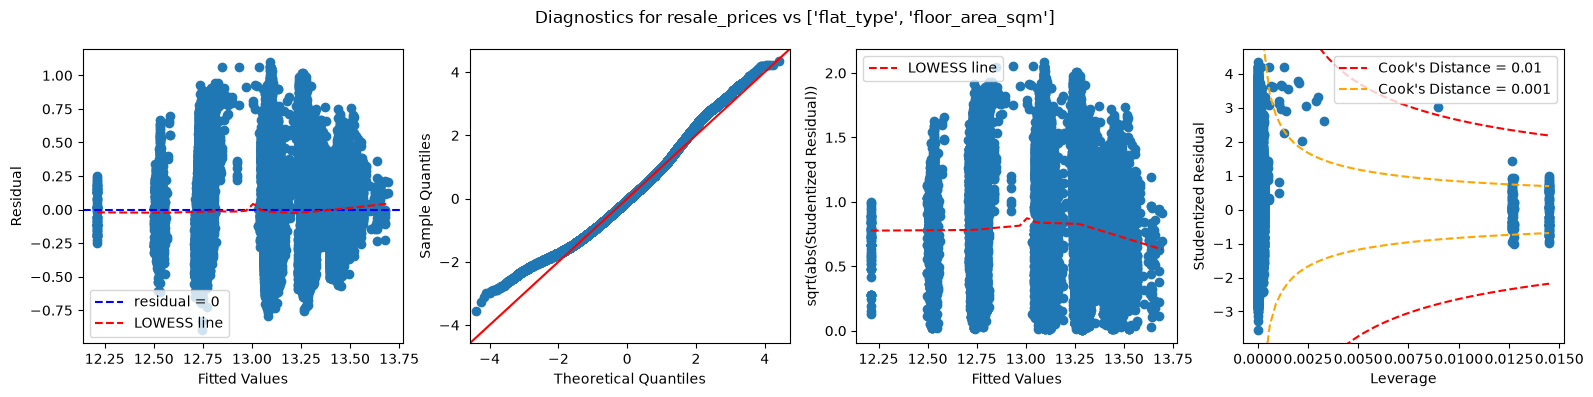

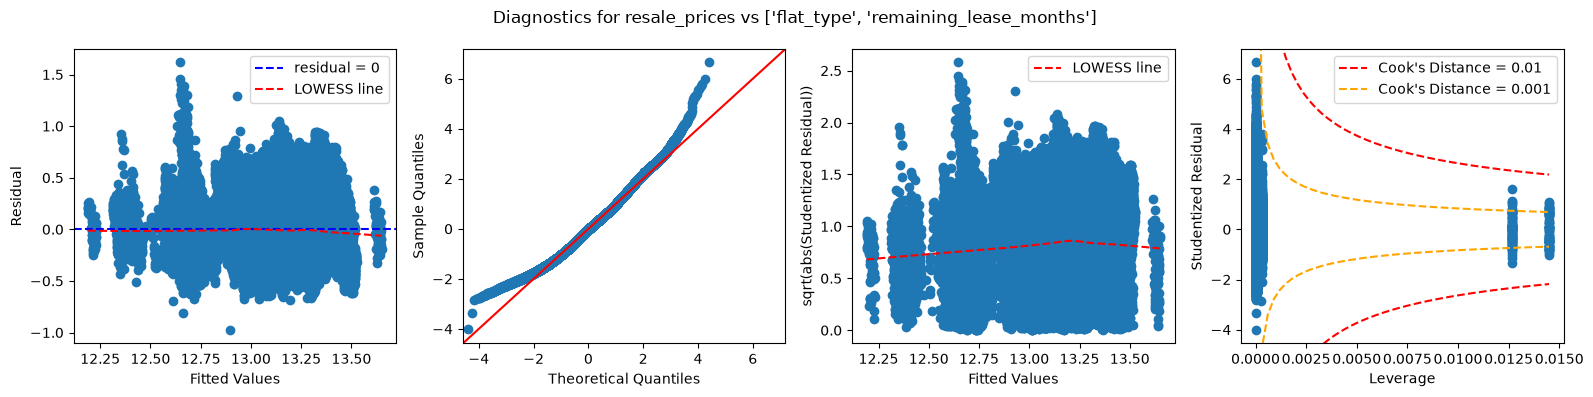

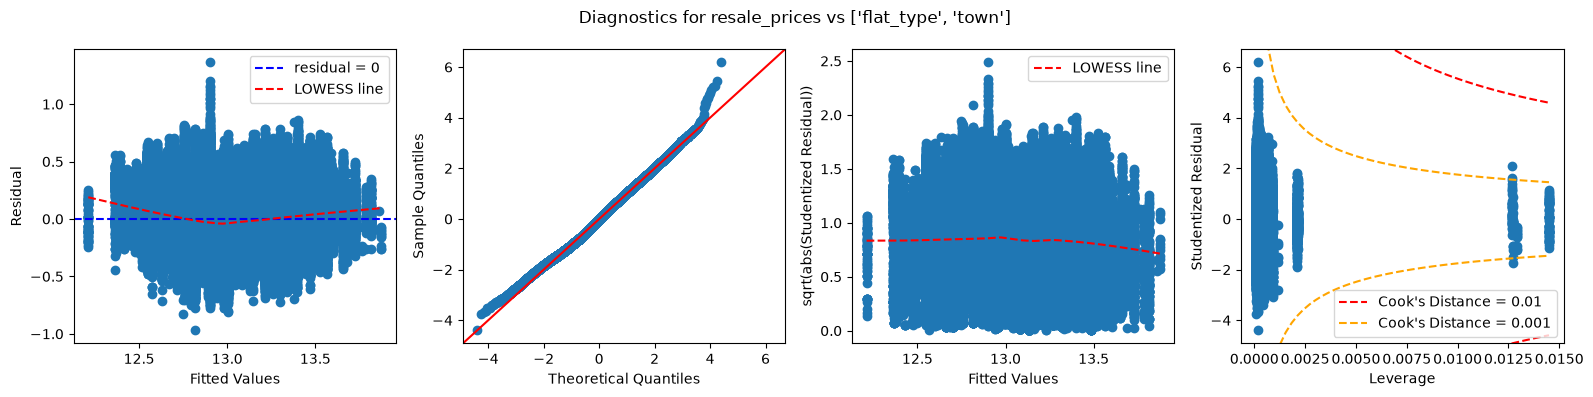

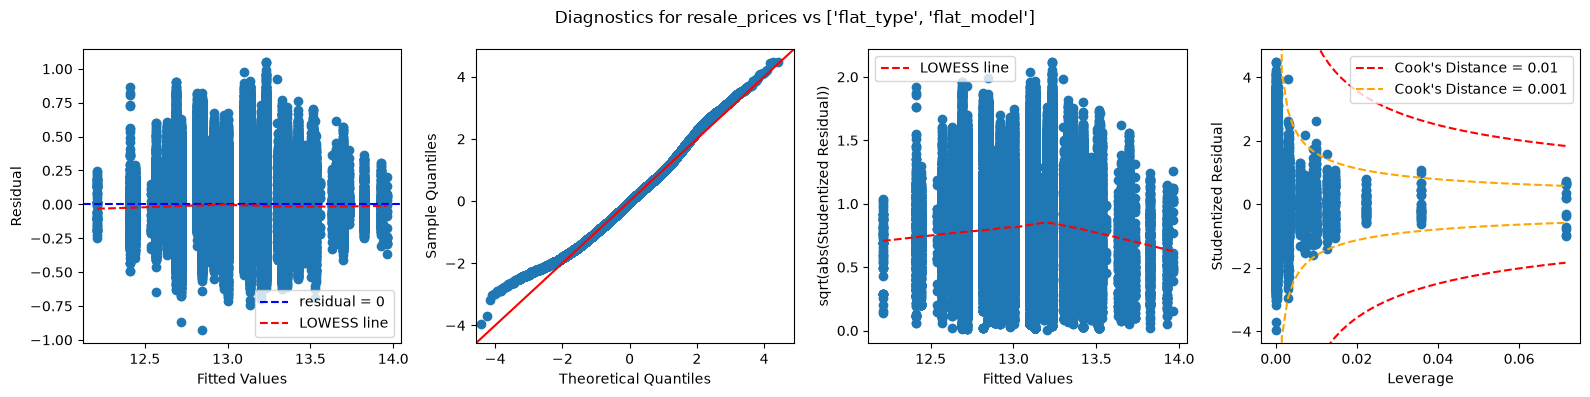

In [22]:
test_predictors(ResalePrices_Train, np.log(y_Train), ['flat_type'], {
    'regdate_months': ['regdate_months'],
    'storey_range_cat': ['storey_range_cat'],
    'floor_area_sqm': ['floor_area_sqm'],
    'remaining_lease_months': ['remaining_lease_months'],
    'town': ['town'],
    'flat_model': ['flat_model'],
})

#### 2 Predictor Model Conclusion
`regdate_months` showed the best R^2 and lowest bic so I will select that as the 2nd predictor to include in the model.

### 3 Predictor Variables

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                 4.701e+04
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:40:50   Log-Likelihood:                 39347.
No. Observations:              190510   AIC:                        -7.868e+04
Df Residuals:                  190501   BIC:                        -7.858e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,f_pvalue,rsquared,rsquared_adj,aic,bic
feature,,,,,
storey_range_cat,0.0,0.663784,0.663770,-78675.971106,-78584.553966
floor_area_sqm,0.0,0.584222,0.584205,-38212.210368,-38120.793228
floor_area_sqm (log),0.0,0.584763,0.584746,-38460.237453,-38368.820313
floor_area_sqm * flat_type,0.0,0.592454,0.592426,-42011.652350,-41869.447910
floor_area_sqm (log) * flat_type,0.0,0.592582,0.592552,-42069.410798,-41917.048898
remaining_lease_months,0.0,0.630075,0.630059,-60473.275981,-60381.858841
remaining_lease_months (log),0.0,0.627078,0.627063,-58936.349035,-58844.931895
flat_model,0.0,0.656027,0.655981,-74294.773677,-74020.522258
town,0.0,0.720398,0.720351,-113755.373319,-113420.177140


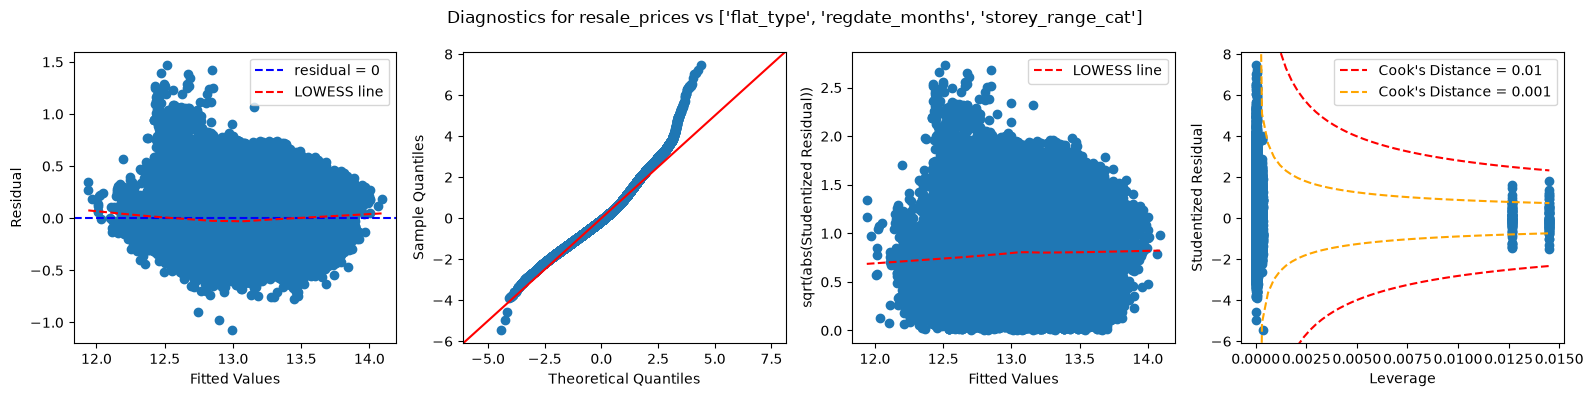

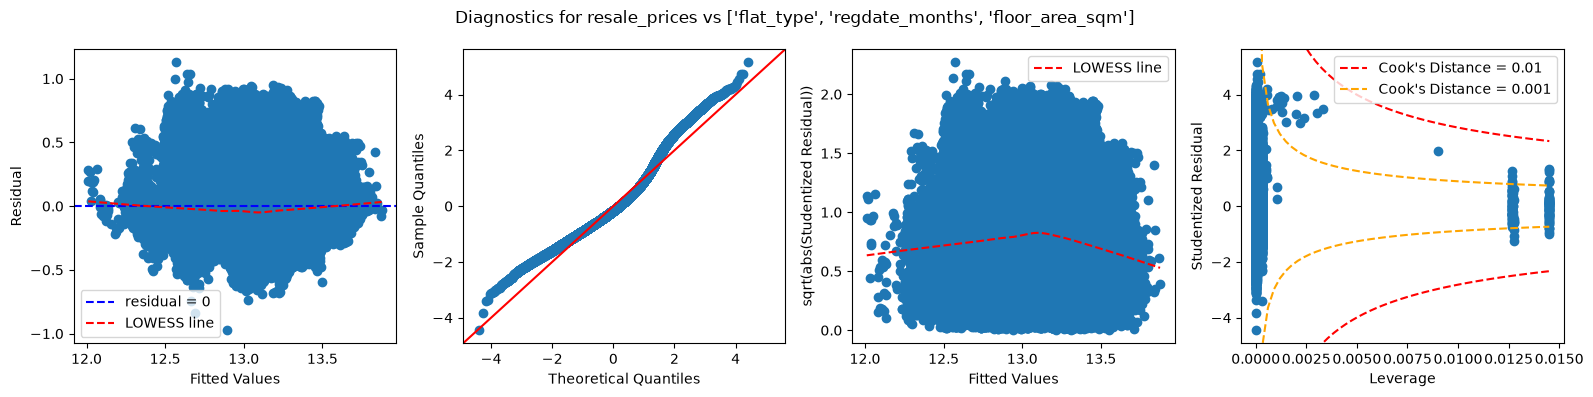

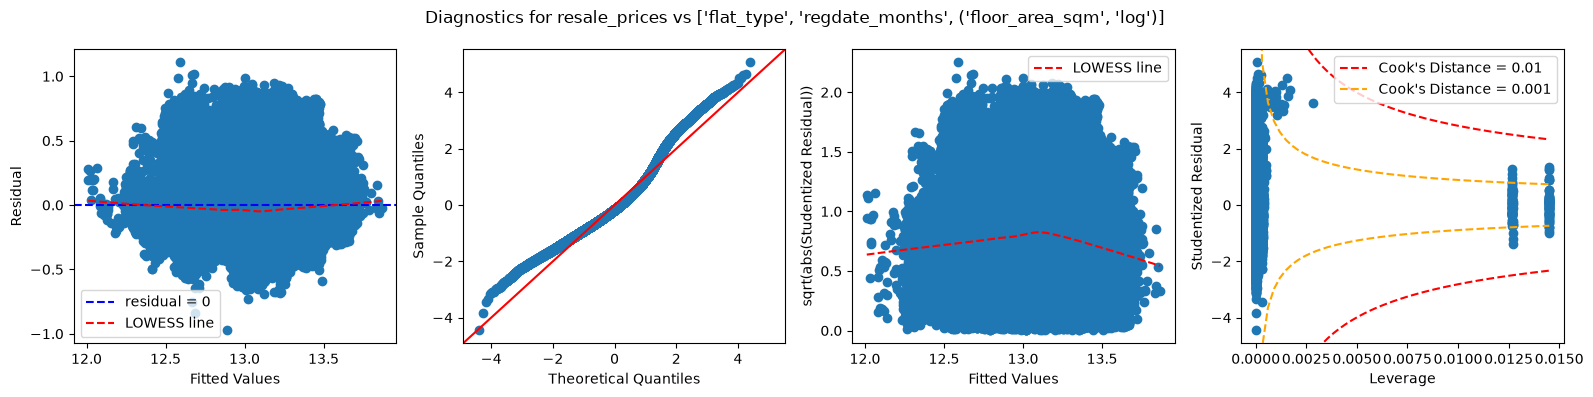

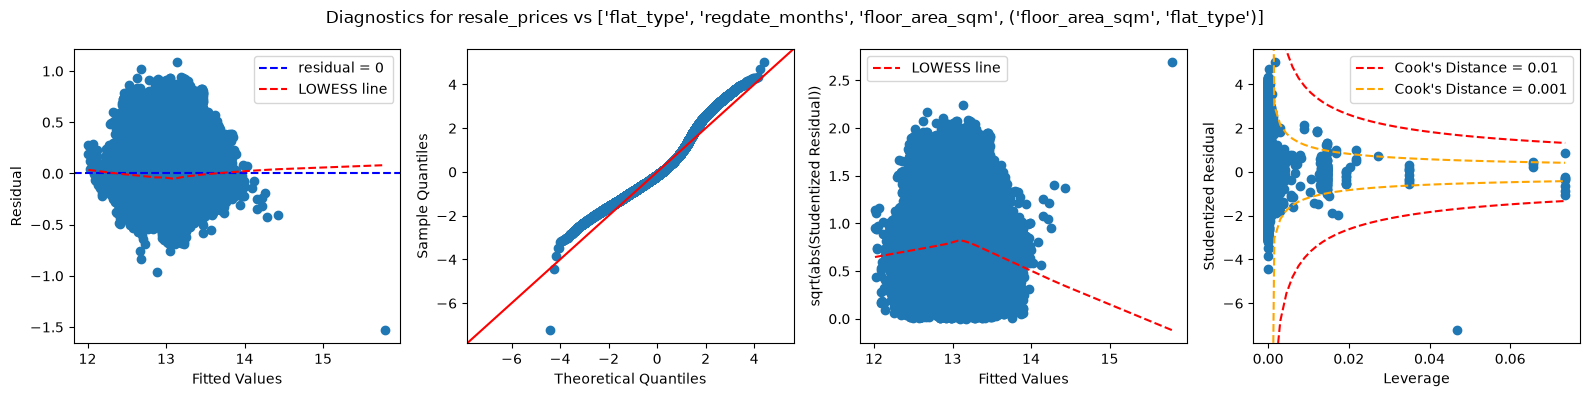

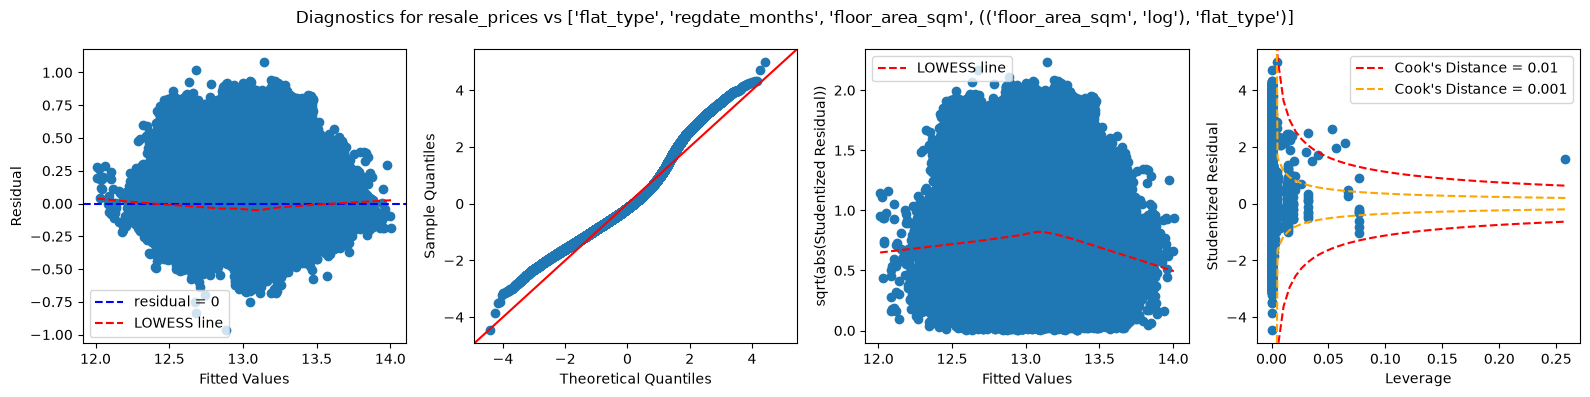

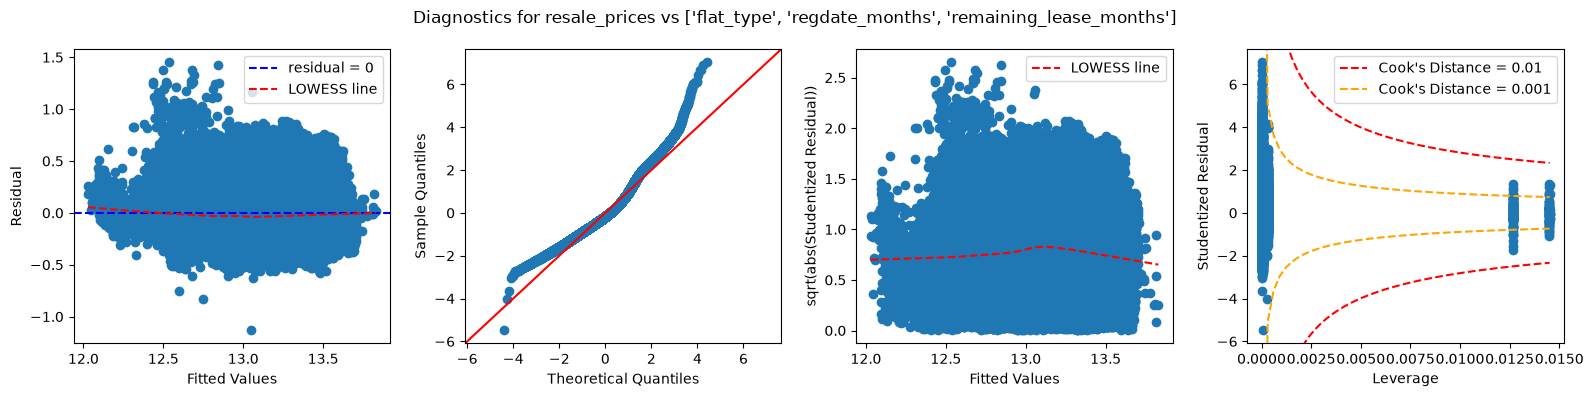

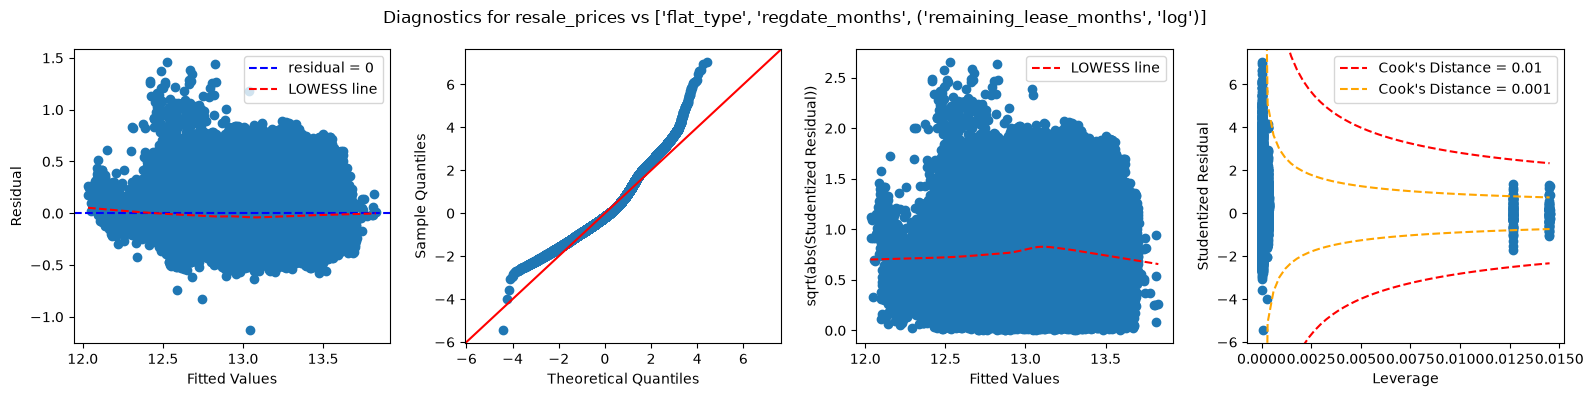

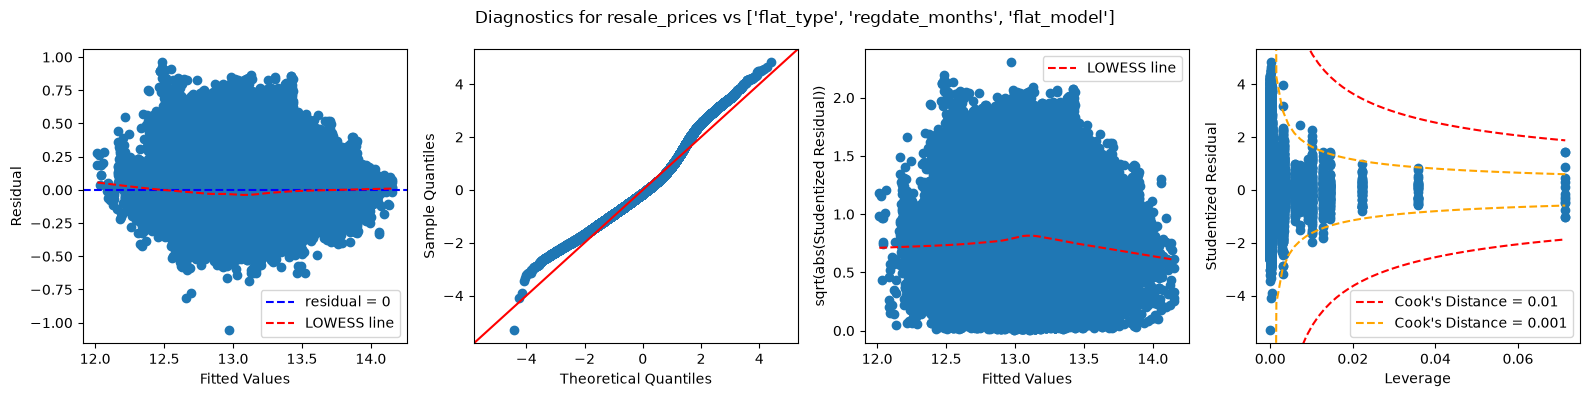

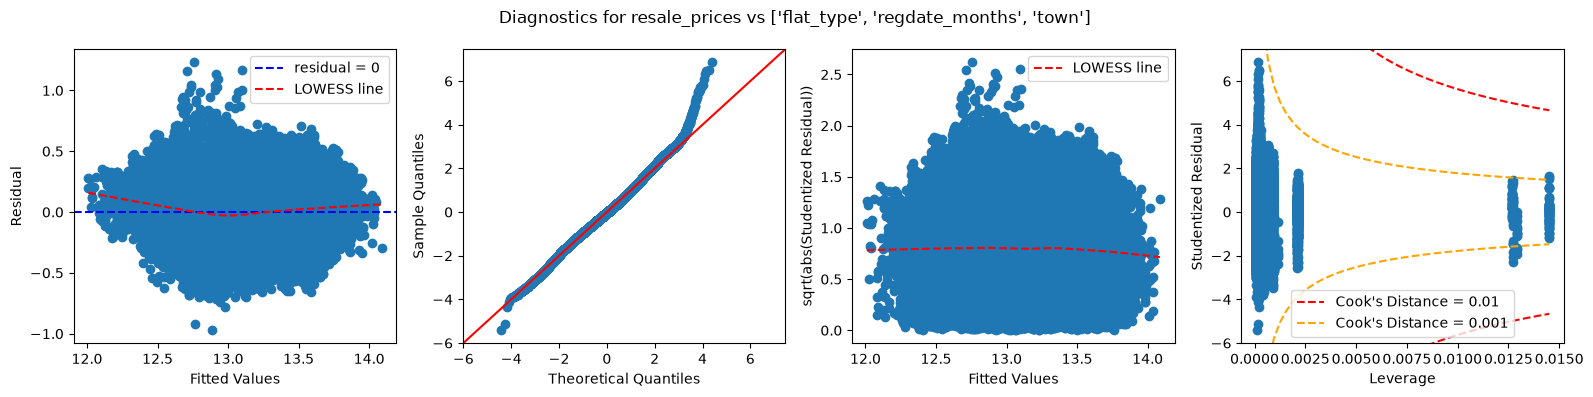

In [23]:
test_predictors(ResalePrices_Train, np.log(y_Train), ['flat_type', 'regdate_months'], {
    'storey_range_cat': ['storey_range_cat'],
    'floor_area_sqm': ['floor_area_sqm'],
    'floor_area_sqm (log)': [('floor_area_sqm', 'log')],
    'floor_area_sqm * flat_type': ['floor_area_sqm', ('floor_area_sqm', 'flat_type')],
    'floor_area_sqm (log) * flat_type': ['floor_area_sqm', (('floor_area_sqm', 'log'), 'flat_type')],
    'remaining_lease_months': ['remaining_lease_months'],
    'remaining_lease_months (log)': [('remaining_lease_months', 'log')],
    'flat_model': ['flat_model'],
    'town': ['town'],

    # in an attempt to correct the apparent non-linearity when we add 'town' as a predictor,
    # I try adding potential polynomial and interaction terms here
    # 'town with floor_area_sqm': ['town', 'floor_area_sqm'],
    # 'town with floor_area_sqm interaction': ['town', 'floor_area_sqm', ('floor_area_sqm', 'town')],
    # 'town with regdate_months polynomial': ['town', ('regdate_months', 2)],
    # 'town with regdate_months interaction': ['town', ('regdate_months', 'town')],
    # 'town with flat_type interaction': ['town', ('flat_type', 'town')], 
})

#### 3 Predictor Model Conclusion
`town` showed the highest R^2 improvement and the best aic / bic values, so I will choose it as the 3rd predictor to include in the model.

However we have to be careful of the slight non-linearity shown in the Residual-Fitted Value plot. 

### 4 Predictor Variables

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                 1.924e+04
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:42:00   Log-Likelihood:                 75184.
No. Observations:              190510   AIC:                        -1.503e+05
Df Residuals:                  190476   BIC:                        -1.500e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,f_pvalue,rsquared,rsquared_adj,aic,bic
feature,,,,,
storey_range_cat,0.0,0.769205,0.769165,-150300.262763,-149954.909124
floor_area_sqm,0.0,0.729210,0.729163,-119854.148283,-119508.794644
floor_area_sqm (polynomial),0.0,0.730563,0.730515,-120806.697339,-120451.186240
floor_area_sqm (log),0.0,0.732104,0.732057,-121900.956174,-121555.602535
floor_area_sqm * flat_type,0.0,0.737434,0.737382,-125719.737666,-125323.596728
floor_area_sqm (log) * flat_type,0.0,0.740584,0.740531,-128017.155519,-127610.857120
floor_area_sqm (log) * town,0.0,0.759704,0.759631,-142564.734046,-141965.443908
remaining_lease_months,0.0,0.838494,0.838466,-218309.575627,-217964.221988
remaining_lease_months (log),0.0,0.840934,0.840907,-221210.479102,-220865.125463


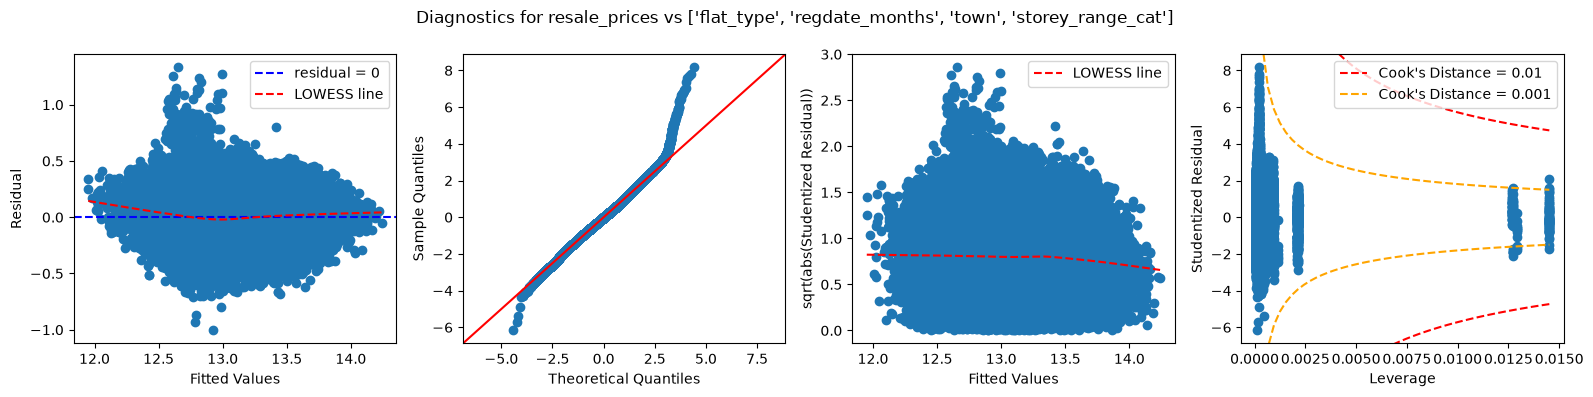

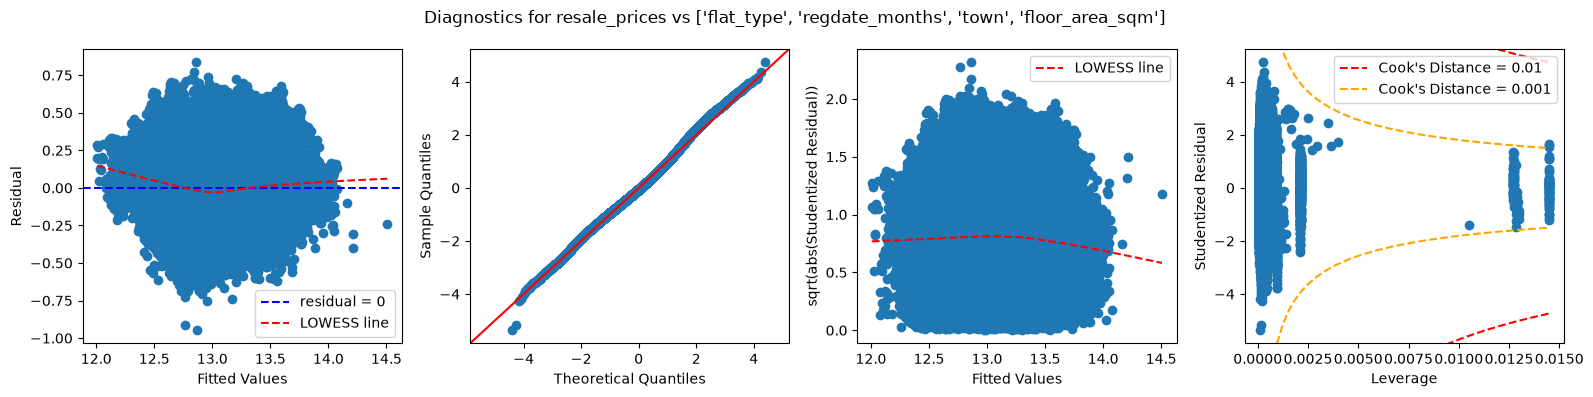

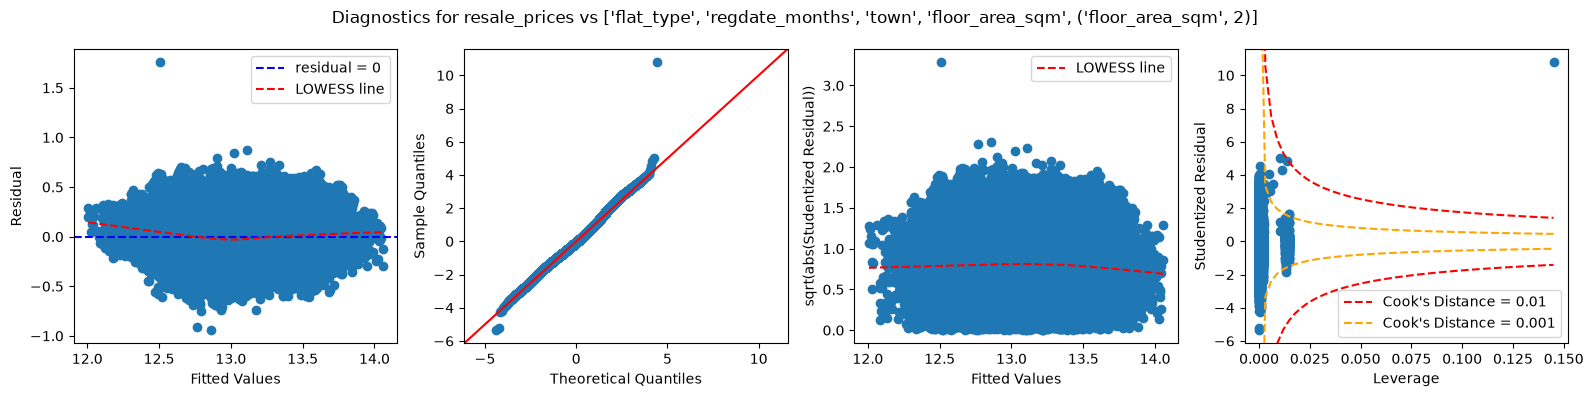

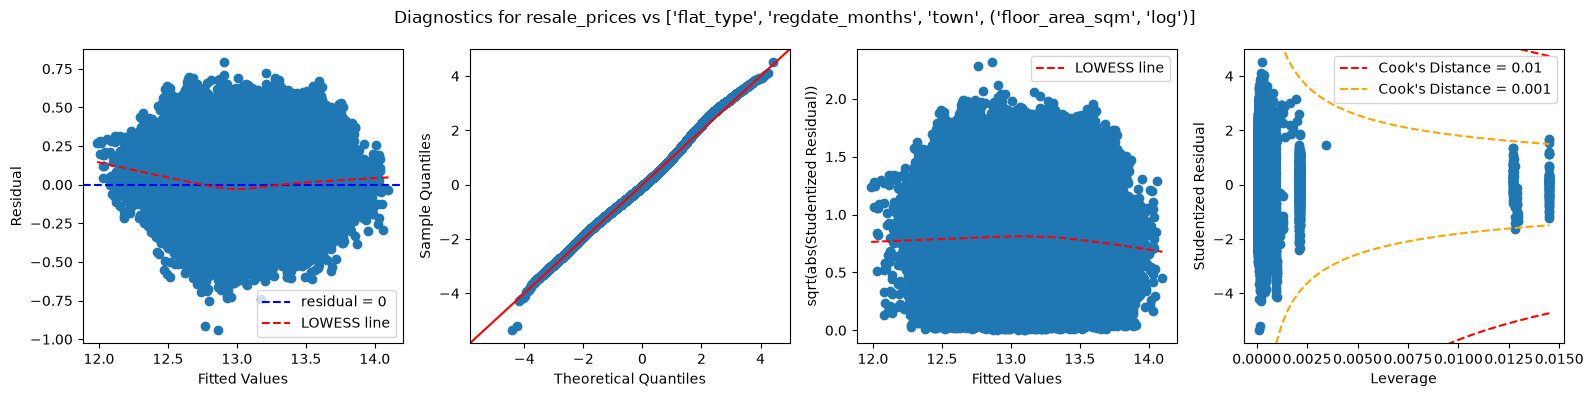

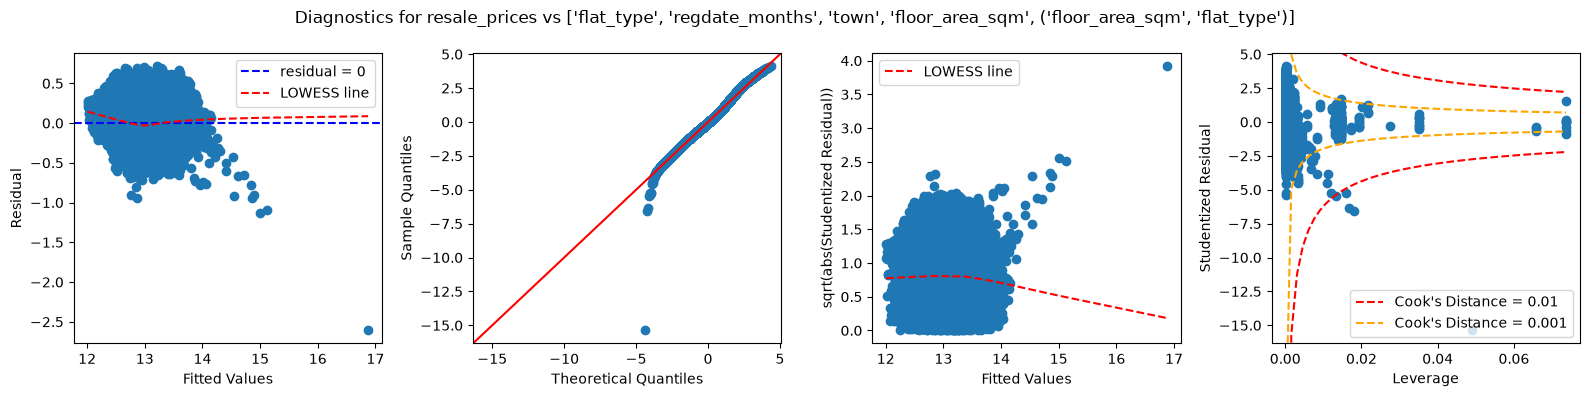

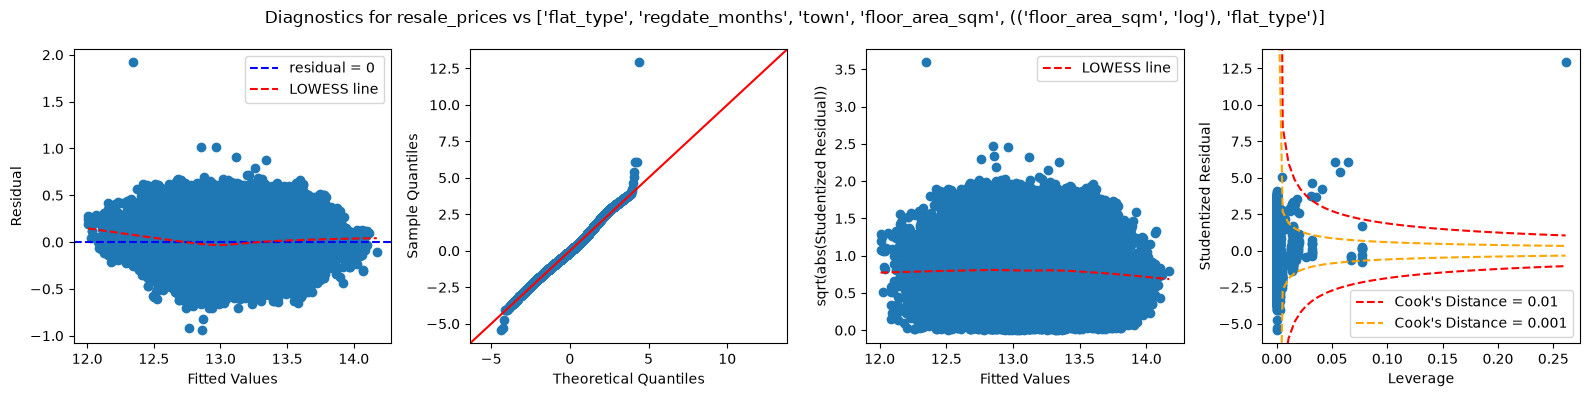

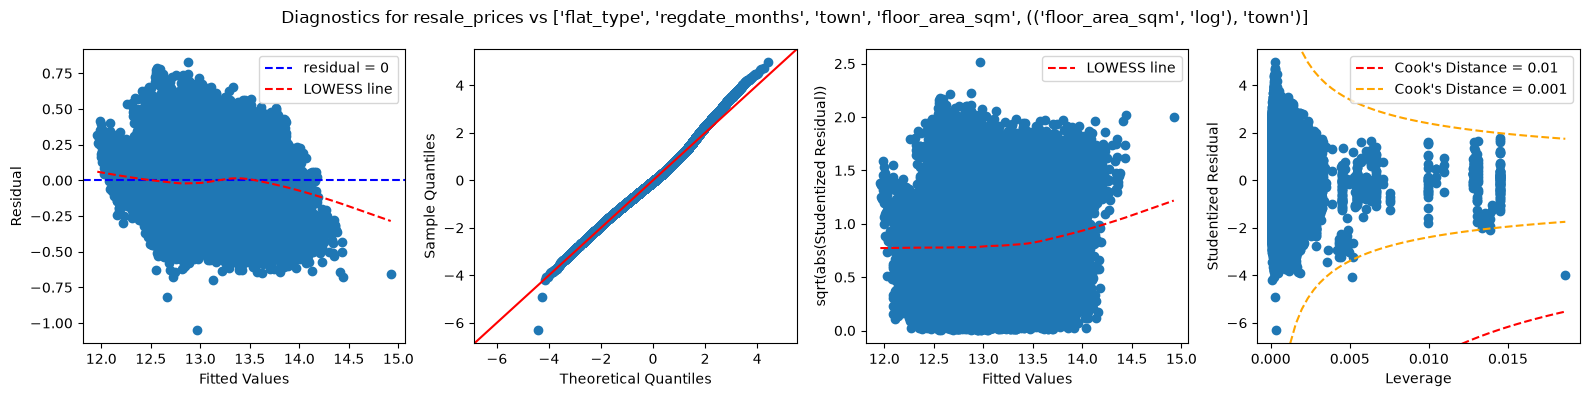

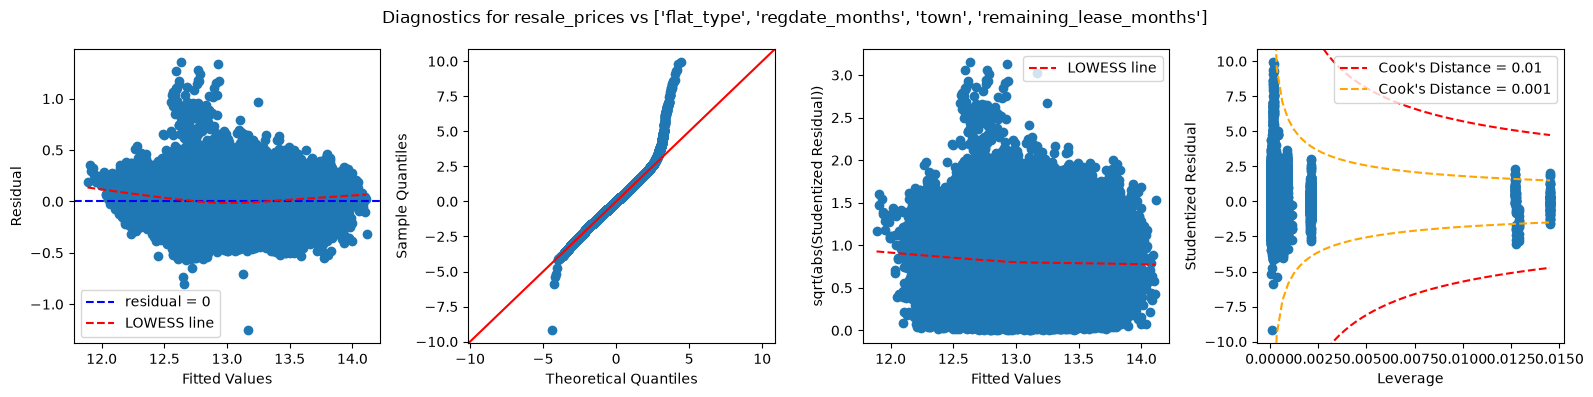

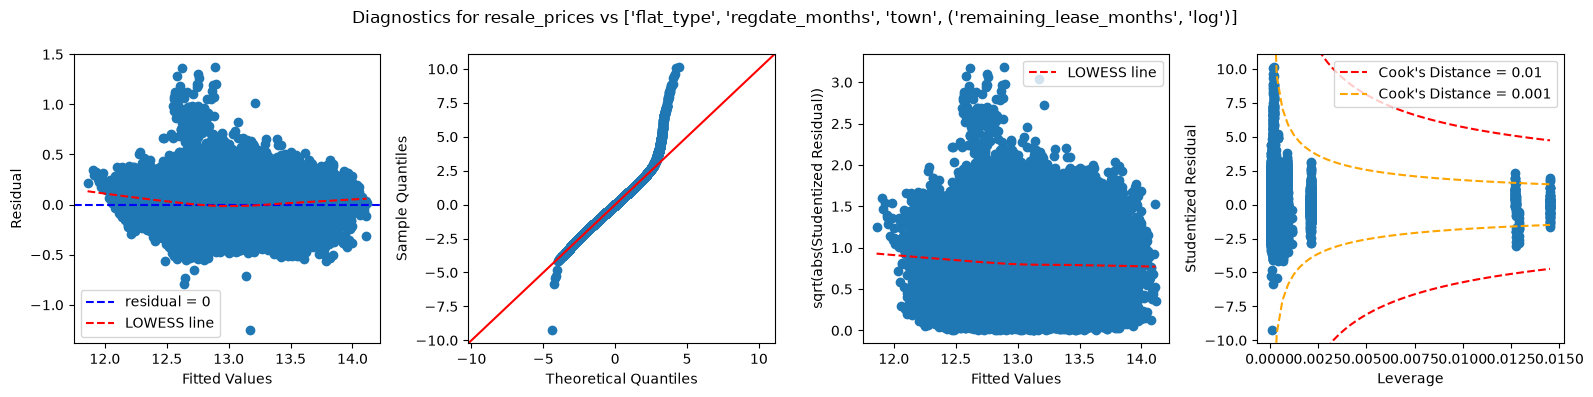

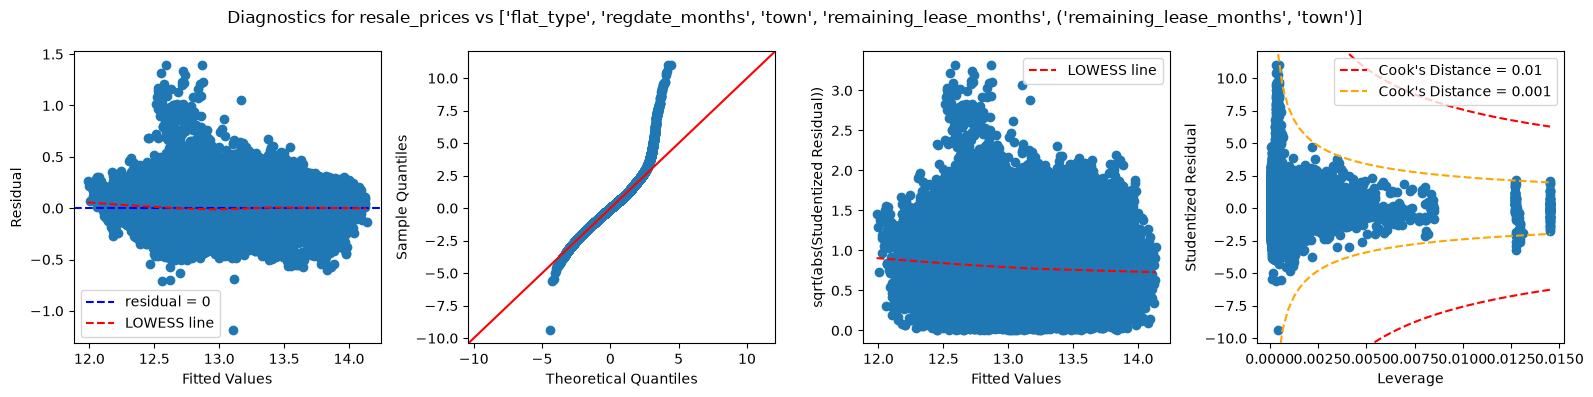

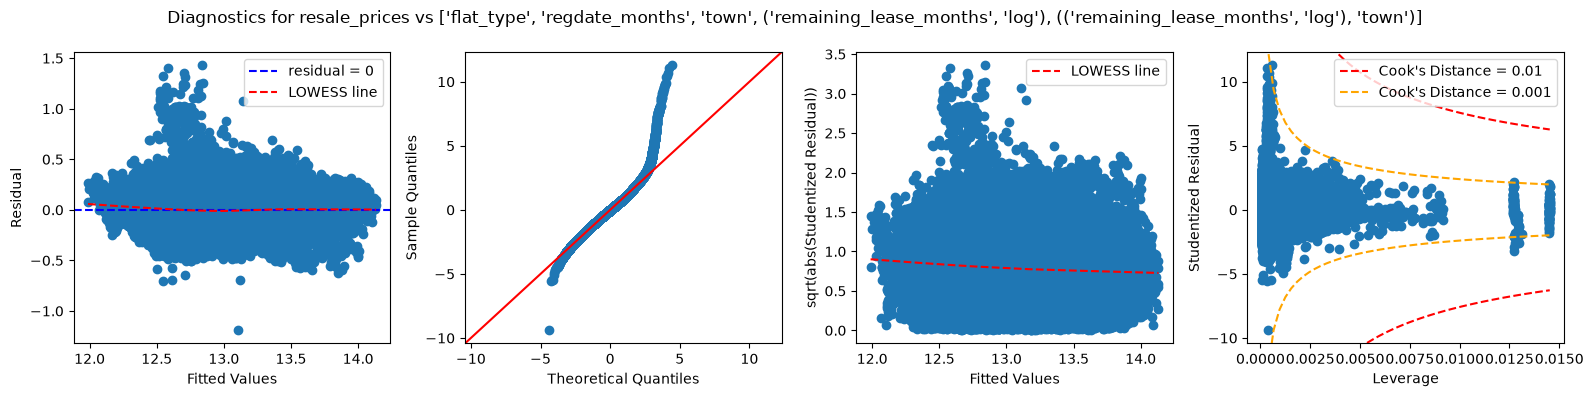

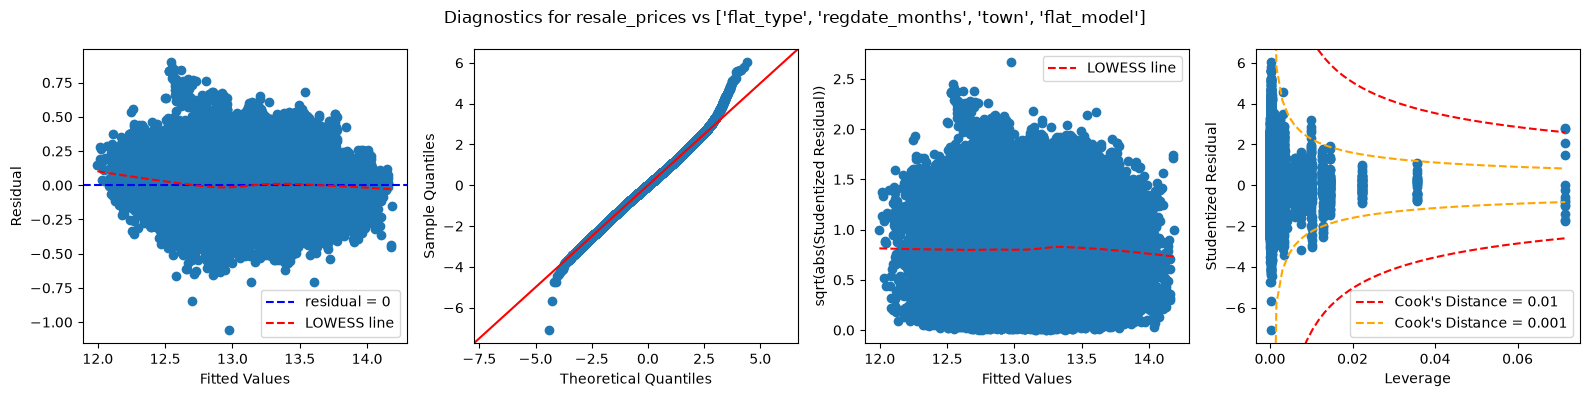

In [24]:
test_predictors(ResalePrices_Train, np.log(y_Train), ['flat_type', 'regdate_months', 'town'], {
    'storey_range_cat': ['storey_range_cat'],
    'floor_area_sqm': ['floor_area_sqm'],
    'floor_area_sqm (polynomial)': ['floor_area_sqm', ('floor_area_sqm', 2)],
    'floor_area_sqm (log)': [('floor_area_sqm', 'log')],
    'floor_area_sqm * flat_type': ['floor_area_sqm', ('floor_area_sqm', 'flat_type')],
    'floor_area_sqm (log) * flat_type': ['floor_area_sqm', (('floor_area_sqm', 'log'), 'flat_type')],
    'floor_area_sqm (log) * town': ['floor_area_sqm', (('floor_area_sqm', 'log'), 'town')],
    'remaining_lease_months': ['remaining_lease_months'],
    'remaining_lease_months (log)': [('remaining_lease_months', 'log')],
    'remaining_lease_months * town': ['remaining_lease_months', ('remaining_lease_months', 'town')],
    'remaining_lease_months (log) * town': [('remaining_lease_months', 'log'), (('remaining_lease_months', 'log'), 'town')],
    'flat_model': ['flat_model'],
})

In [25]:
# test_predictors(ResalePrices_Train, np.log(y_Train), ['flat_type', 'regdate_months', 'town', 'remaining_lease_months', ('remaining_lease_months', 'town'), 'flat_model', 'storey_range_cat'], [
#     # ['storey_range_cat'],
#     ['floor_area_sqm'], 

#     ['floor_area_sqm', ('floor_area_sqm', 'flat_type')],
#     ['floor_area_sqm', ('floor_area_sqm', 'town')],
#     ['floor_area_sqm', ('floor_area_sqm', 2)],
#     ['floor_area_sqm', ('floor_area_sqm', 2), ('floor_area_sqm', 'flat_type'), (('floor_area_sqm', 2), 'flat_type')],
#     ['floor_area_sqm', ('floor_area_sqm', 2), ('floor_area_sqm', 'town'), (('floor_area_sqm', 2), 'town')],

#     [('floor_area_sqm', 'log')],
#     [('floor_area_sqm', 'log'), (('floor_area_sqm', 'log'), 'flat_type')],
#     [('floor_area_sqm', 'log'), (('floor_area_sqm', 'log'), 'town')],
# ])
# we need to beat: 0.86, I mean we will definitely beat it but is it significant is the question, if the adjustment is small then maybe it's not worth it
# with flat_model we need to beat 0.877 but it's like a small improvement only - is it worth it? we may overfit...

### Evaluation of Models
So, when trying to predict prices for a certain resale HDB flat, which model should we actually use?
- Which models are more accurate?
- Which models follow the assumptions for linear regression better and thus have more interpretable results?

I aim to answer these questions by computing the RMSE and R^2 on the test (out-of-sample) data.

#### 1-Predictor Models